In [110]:
import pandas as pd
import numpy as np
from datetime import datetime
import re
import ast
import json
import os
from tqdm.notebook import tqdm  # or from tqdm import tqdm


# Translation Table

NB: HERE WE WORK ONLY WITH ARTICLES WHICH HAVE FULL-TEXT -> CAN IMPACT THE NUMBER OF REPORTED ENTITIES. IF THEY HAD NO STUDIES WITH ANNOTATIONS, THEY ARE EXCLUDED

In [996]:
old_ds_analysis = False
full_ds_analysis = False
neuro_ds_analysis_17 = False

In [997]:
# datasets prepared in Translation_05_0_Prep_Pairs_for_Associations
# for the old analysis translation_table_drug_disease_OLD.csv
if old_ds_analysis:
    file_path = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/out/translation_table_drug_disease_OLD.csv"
    dataset_name = "OLD dataset"
elif full_ds_analysis:
    file_path = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/out/translation_table_drug_disease_FULL.csv"
    dataset_name = "FULL dataset"
elif neuro_ds_analysis_17:
    file_path = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/out/translation_table_drug_disease_NEURO_17.csv"
    dataset_name = "NEURO_17 dataset"
else:
    file_path = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/out/translation_table_drug_disease_NEURO.csv"
    dataset_name = "NEURO dataset"

print(f"\nLoading translation table: {dataset_name}")
print(f"File path: {file_path}")

translation_table = pd.read_csv(file_path)

print("\nData loaded successfully")
print(f"Rows: {translation_table.shape[0]:,}")
print(f"Columns: {translation_table.shape[1]}")
print(f"Shape: {translation_table.shape}")

print("\nPreview:")
translation_table.head()


Loading translation table: NEURO dataset
File path: /shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/out/translation_table_drug_disease_NEURO.csv

Data loaded successfully
Rows: 17,158
Columns: 31
Shape: (17158, 31)

Preview:


,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,trial_completion_year,phase,overall_status,...,trial_completion_year_first_completed_phase3,fda_merged_umls_label,fda_disease_mondo_term_norm,fda_earliest_year,fda_disease,fda_documents,fda_disease<>drug,fda_AP,fda_only,matched_term
0,obsolete disorder involving pain <> bupivacaine,"['NCT00001724', 'NCT00008476', 'NCT00050362', ...",MONDO:0021668,C0006400,obsolete disorder involving pain,bupivacaine,"[1997.0, 2001.0, 2002.0, 1998.0, 2005.0, 2006....","[2001.0, 2004.0, 2004.0, 2000.0, 2013.0, 2006....","['PHASE2', 'PHASE2', 'PHASE2', 'PHASE3', 'PHAS...","['COMPLETED', 'COMPLETED', 'COMPLETED', 'COMPL...",...,2000.0,Bupivacaine,obsolete disorder involving pain,1981.0,pain,"['ANDA070552', 'ANDA070553', 'ANDA070966', 'AN...",obsolete disorder involving pain <> bupivacaine,True,NaN,obsolete disorder involving pain
1,obsolete disorder involving pain <> lidocaine,"['NCT00001724', 'NCT00006070', 'NCT00006299', ...",MONDO:0021668,C0023660,obsolete disorder involving pain,lidocaine,"[1997.0, 2000.0, 1999.0, 2001.0, 2001.0, 2002....","[2001.0, 2004.0, 2004.0, 2004.0, 2003.0, 2004....","['PHASE2', 'PHASE2', 'PHASE2', 'PHASE2', 'PHAS...","['COMPLETED', 'COMPLETED', 'COMPLETED', 'COMPL...",...,2004.0,Lidocaine,obsolete disorder involving pain,1999.0,pain,"['ANDA076453', 'ANDA202346', 'ANDA206297', 'AN...",obsolete disorder involving pain <> lidocaine,True,NaN,obsolete disorder involving pain
2,obsolete disorder involving pain <> morphine,"['NCT00003687', 'NCT00004390', 'NCT00004696', ...",MONDO:0021668,C0026549,obsolete disorder involving pain,morphine,"[1998.0, 1995.0, 1994.0, 2000.0, 2001.0, 2001....","[2009.0, nan, 1998.0, 2003.0, 2006.0, 2004.0, ...","['PHASE3', 'PHASE3', nan, 'PHASE1/PHASE2', 'PH...","['COMPLETED', 'COMPLETED', 'COMPLETED', 'COMPL...",...,2001.0,Morphine,obsolete disorder involving pain,1984.0,pain,"['ANDA073509', 'ANDA073510', 'ANDA078761', 'AN...",obsolete disorder involving pain <> morphine,True,NaN,obsolete disorder involving pain
3,obsolete disorder involving pain <> acetaminophen,"['NCT00000425', 'NCT00000731', 'NCT00006070', ...",MONDO:0021668,C0000970,obsolete disorder involving pain,acetaminophen,"[1996.0, nan, 2000.0, 1999.0, 2001.0, 2002.0, ...","[2001.0, 1990.0, 2004.0, 2004.0, 2004.0, 2004....","['PHASE3', nan, 'PHASE2', 'PHASE2', 'PHASE2', ...","['COMPLETED', 'COMPLETED', 'COMPLETED', 'COMPL...",...,2001.0,Acetaminophen,obsolete disorder involving pain,1980.0,pain; pains,"['ANDA040330', 'ANDA040400', 'ANDA040405', 'AN...",obsolete disorder involving pain <> acetaminophen,True,NaN,obsolete disorder involving pain
4,glioblastoma <> temozolomide,"['NCT00003464', 'NCT00004200', 'NCT00006353', ...",MONDO:0018177,C0076080,glioblastoma,temozolomide,"[1997.0, 1999.0, 2000.0, 2000.0, 2002.0, 2001....","[2003.0, nan, nan, 2006.0, 2012.0, 2005.0, nan...","['PHASE2', 'PHASE2', 'PHASE3', 'PHASE2', 'PHAS...","['COMPLETED', 'COMPLETED', 'COMPLETED', 'COMPL...",...,2005.0,Temozolomide,glioblastoma,1999.0,glioblastoma; newly diagnosed glioblastoma,"['ANDA201528', 'ANDA201742', 'ANDA204639', 'AN...",glioblastoma <> temozolomide,True,NaN,glioblastoma


In [998]:
keep_linked_only = False
if keep_linked_only:
    # Filter to keep rows where both IDs are NOT -1
    translation_table = translation_table[
        (translation_table['merged_mondo_termid'] != "-1") & 
        (translation_table['merged_umls_termid'] != "-1")
    ]
    
    # Reset index for a clean dataframe
    translation_table = translation_table.reset_index(drop=True)

In [999]:
n_diseases = translation_table["merged_mondo_label"].nunique()
n_drugs = translation_table["merged_umls_label"].nunique()

print("\n=== Entity coverage summary ===")
print(f"Total unique diseases: {n_diseases:,}")
print(f"Total unique drugs: {n_drugs:,}")



=== Entity coverage summary ===
Total unique diseases: 827
Total unique drugs: 3,974


In [1000]:
translation_table.normalized_key.nunique()

17158

### filer for translated

In [1001]:
translation_table["translation_status"] = np.where(
    (
        translation_table["at_least_one_phase4"]
        | translation_table["at_least_one_phase3_completed"]
        | translation_table["fda_AP"]
    ),
    "approved",
    "failed",
)
print("=== Translation status summary ===")
print(translation_table["translation_status"].value_counts())
print()

=== Translation status summary ===
translation_status
failed      9889
approved    7269
Name: count, dtype: int64



In [1002]:
translation_table["min_relevant_clinical_year"] = (
    translation_table[
        [
            "min_phase_4_year",
            "trial_completion_year_first_completed_phase3",
            "fda_earliest_year",
        ]
    ]
    .min(axis=1, skipna=True)
)
translation_table["min_relevant_clinical_year"] = (
    translation_table["min_relevant_clinical_year"]
    .round()
    .astype("Int64")   # nullable integer dtype
)


In [1003]:
df_translated = translation_table[translation_table['translation_status']=="approved"]
df_translated.shape

(7269, 33)

In [1004]:

def to_list(x):
    if not isinstance(x, str) or not x.startswith('['):
        return x if isinstance(x, list) else []
    
    # Replace 'nan' with 'None' so the parser understands it
    cleaned_x = x.replace('nan', 'None')
    
    try:
        return ast.literal_eval(cleaned_x)
    except Exception as e:
        # If literal_eval still fails, try json.loads as a backup
        try:
            return json.loads(cleaned_x.replace("'", '"'))
        except:
            print(f"Failed to parse: {x[:50]}...") # Print first 50 chars of error
            return []

# Apply the fix
df_translated.loc[:, 'preclinical_doc_ids'] = df_translated['preclinical_doc_ids'].apply(to_list)
df_translated.loc[:, 'pub_year'] = df_translated['pub_year'].apply(to_list)

df_translated.head(2)

,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,trial_completion_year,phase,overall_status,...,fda_disease_mondo_term_norm,fda_earliest_year,fda_disease,fda_documents,fda_disease<>drug,fda_AP,fda_only,matched_term,translation_status,min_relevant_clinical_year
0,obsolete disorder involving pain <> bupivacaine,"['NCT00001724', 'NCT00008476', 'NCT00050362', ...",MONDO:0021668,C0006400,obsolete disorder involving pain,bupivacaine,"[1997.0, 2001.0, 2002.0, 1998.0, 2005.0, 2006....","[2001.0, 2004.0, 2004.0, 2000.0, 2013.0, 2006....","['PHASE2', 'PHASE2', 'PHASE2', 'PHASE3', 'PHAS...","['COMPLETED', 'COMPLETED', 'COMPLETED', 'COMPL...",...,obsolete disorder involving pain,1981.0,pain,"['ANDA070552', 'ANDA070553', 'ANDA070966', 'AN...",obsolete disorder involving pain <> bupivacaine,True,NaN,obsolete disorder involving pain,approved,1981
1,obsolete disorder involving pain <> lidocaine,"['NCT00001724', 'NCT00006070', 'NCT00006299', ...",MONDO:0021668,C0023660,obsolete disorder involving pain,lidocaine,"[1997.0, 2000.0, 1999.0, 2001.0, 2001.0, 2002....","[2001.0, 2004.0, 2004.0, 2004.0, 2003.0, 2004....","['PHASE2', 'PHASE2', 'PHASE2', 'PHASE2', 'PHAS...","['COMPLETED', 'COMPLETED', 'COMPLETED', 'COMPL...",...,obsolete disorder involving pain,1999.0,pain,"['ANDA076453', 'ANDA202346', 'ANDA206297', 'AN...",obsolete disorder involving pain <> lidocaine,True,NaN,obsolete disorder involving pain,approved,1999


In [1005]:
df_translated[df_translated['normalized_key']=='type 2 diabetes mellitus <> metformin']

,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,trial_completion_year,phase,overall_status,...,fda_disease_mondo_term_norm,fda_earliest_year,fda_disease,fda_documents,fda_disease<>drug,fda_AP,fda_only,matched_term,translation_status,min_relevant_clinical_year


#### exclude studies after clinical

In [1006]:
df_translated['preclinical_ids_before_clinical'] = df_translated.apply(
    lambda row: [
        doc_id for doc_id, year in zip(row['preclinical_doc_ids'], row['pub_year']) 
        if pd.notnull(row['min_relevant_clinical_year']) and pd.notnull(year) and float(year) <= row['min_relevant_clinical_year']
    ], 
    axis=1
)
df_translated['preclinical_count_before_clinical'] = df_translated['preclinical_ids_before_clinical'].str.len()
df_translated.shape

/tmp/ipykernel_1335175/1590931843.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_translated['preclinical_ids_before_clinical'] = df_translated.apply(
/tmp/ipykernel_1335175/1590931843.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_translated['preclinical_count_before_clinical'] = df_translated['preclinical_ids_before_clinical'].str.len()


(7269, 35)

In [1007]:
translated_pmids = list(set([
    pmid 
    for sublist in df_translated['preclinical_ids_before_clinical'] 
    for pmid in sublist
]))
len(translated_pmids)

20158

In [1008]:
translated_pmids[:5]

[9306115, 21495821, 25296915, 34078742, 2883637]

### not translated (and not recently entered clinical)

In [1009]:
df_failed = translation_table[translation_table['translation_status']=="failed"]
df_failed.shape

(9889, 33)

In [1010]:
df_recent = df_failed[df_failed['min_trial_start_year']>=2015]
df_recent.shape

(4728, 33)

In [1011]:
df_failed = df_failed[df_failed['min_trial_start_year']<2015]
df_failed.shape

(5025, 33)

In [1012]:
df_failed.loc[:, 'max_trial_start_year'] = pd.to_numeric(df_failed['max_trial_start_year'], errors='coerce')
df_failed.loc[:, 'preclinical_doc_ids'] = df_failed['preclinical_doc_ids'].apply(to_list)
df_failed.loc[:, 'pub_year'] = df_failed['pub_year'].apply(to_list)

In [1013]:
df_failed["min_relevant_clinical_year"] = (
    df_failed["max_trial_start_year"]
    .round()
    .astype("Int64")   # nullable integer dtype
)

#### exclude studies after clinical

In [1014]:
df_failed['preclinical_ids_before_latest_trial'] = df_failed.apply(
    lambda row: [
        doc_id for doc_id, year in zip(row['preclinical_doc_ids'], row['pub_year']) 
        if pd.notnull(row['max_trial_start_year']) and pd.notnull(year) and float(year) <= row['max_trial_start_year']
    ], 
    axis=1
)
df_failed['preclinical_count_before_latest_trial'] = df_failed['preclinical_ids_before_latest_trial'].str.len()
df_failed.shape

(5025, 35)

In [1015]:
failed_pmids = list(set([
    pmid 
    for sublist in df_failed['preclinical_ids_before_latest_trial'] 
    for pmid in sublist
]))
len(failed_pmids)

11692

In [1019]:
data_for_timeline = pd.concat([df_failed, df_translated], axis=0)
data_for_timeline.to_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/out/translation_table_for_timeline.csv", index=False)

# Get relevant preclinical studies

In [963]:
def summarize_preclinical_retrieval(
    df_original,
    df_targets,
    df_retrieved,
    target_pmid_col="pmid",
    retrieved_pmid_col="PMID",
    key_col="normalized_key",
    relevant_preclin_cound_col="preclinical_count_before_clinical", #"preclinical_count_before_latest_trial",
    verbose=True,
):
    """
    Summarize retrieval coverage after joining target PMIDs to a preclinical dataset.
    """

    # --- PMID-level retrieval ---
    target_pmids = df_targets[target_pmid_col].nunique()
    retrieved_pmids = df_retrieved[retrieved_pmid_col].nunique()

    pct_pmids_retrieved = 100 * retrieved_pmids / target_pmids if target_pmids > 0 else 0.0

    # --- normalized_key-level coverage ---
    keys_before = set(df_targets[key_col].dropna())
    keys_after = set(df_retrieved[key_col].dropna())

    n_keys_before = len(keys_before)
    n_keys_after = len(keys_after)

    keys_with_no_articles = keys_before - keys_after
    n_keys_with_no_articles = len(keys_with_no_articles)

    pct_keys_retrieved = 100 * n_keys_after / n_keys_before if n_keys_before > 0 else 0.0
    pct_keys_missing = 100 * n_keys_with_no_articles / n_keys_before if n_keys_before > 0 else 0.0

    if verbose:
        print("\n" + "=" * 60)
        print("PRECLINICAL RETRIEVAL SUMMARY")
        print("=" * 60)

        # --- Target population ---
        print("\n[1] Target drug–disease pairs")
        target_entity_pairs = df_original[key_col].nunique()
        print(f"Total target pairs: {target_entity_pairs:,}")

        missing_before_clinical = (
            df_original[relevant_preclin_cound_col] == 0
        ).sum()
        print(
            f"Pairs with NO preclinical studies before clinical: "
            f"{missing_before_clinical:,} "
            f"({100 * missing_before_clinical / target_entity_pairs:.1f}%)"
        )
        print(
            f"Pairs with ≥1 preclinical study before clinical: "
            f"{target_entity_pairs - missing_before_clinical:,}"
        )
        
        missing_before_clinical_g1 = (
            df_original[relevant_preclin_cound_col] <= 1
        ).sum()
        print(
            f"Pairs with less than 2 preclinical studies before clinical: "
            f"{missing_before_clinical_g1:,} "
            f"({100 * missing_before_clinical_g1 / target_entity_pairs:.1f}%)"
        )
        print(
            f"Pairs with ≥2 preclinical study before clinical: "
            f"{target_entity_pairs - missing_before_clinical_g1:,}"
        )
        

        # --- PMID retrieval ---
        print("\n[2] PMID-level retrieval")
        print(
            f"Target PMIDs:    {target_pmids:,}\n"
            f"Retrieved PMIDs: {retrieved_pmids:,}\n"
            f"Retrieval rate:  {pct_pmids_retrieved:.1f}%"
        )

        # --- normalized_key coverage ---
        print("\n[3] normalized_key coverage (entity-level)")
        print(
            f"Keys with ≥1 retrieved article: {n_keys_after:,} / {n_keys_before:,} "
            f"({pct_keys_retrieved:.1f}%)"
        )
        print(
            f"Keys with NO retrieved articles: {n_keys_with_no_articles:,} / {n_keys_before:,} "
            f"({pct_keys_missing:.1f}%)"
        )

        print("=" * 60 + "\n")


    return {
        "target_pmids": target_pmids,
        "retrieved_pmids": retrieved_pmids,
        "pct_pmids_retrieved": pct_pmids_retrieved,
        "n_keys_before": n_keys_before,
        "n_keys_after": n_keys_after,
        "n_keys_with_no_articles": n_keys_with_no_articles,
        "pct_keys_retrieved": pct_keys_retrieved,
        "pct_keys_missing": pct_keys_missing,
        "keys_with_no_articles": keys_with_no_articles,
    }


In [964]:
base_annotation_dir = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text/model_predictions"

df_path_current_dataset = f"{base_annotation_dir}/full_text_combined_all_annotations_metadata.csv" #full_text_combined_all_annotations.csv" older version with less studies 340380. 'disease_term_mondo_norm','drug_term_umls_norm'
# ,'animal_age'
preclin_dataset = pd.read_csv(df_path_current_dataset)[['PMID','title', 'rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size', 'animal_species','animal_sex','animal_strain','animal_number', 'assay_type', 'first_author_country']]
preclin_dataset['animal_sex'] = preclin_dataset['animal_sex'].apply(lambda x:x.replace("sex-",""))
#primekg_cleaned = pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/entities_drug_disease_preclin.csv")
#preclin_dataset = preclin_dataset.merge(primekg_cleaned[['PMID','merged_mondo_label','merged_umls_label']], on="PMID", how="left")

preclin_dataset.head()

/tmp/ipykernel_1335175/2323375893.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  preclin_dataset = pd.read_csv(df_path_current_dataset)[['PMID','title', 'rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size', 'animal_species','animal_sex','animal_strain','animal_number', 'assay_type', 'first_author_country']]


,PMID,title,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_strain,animal_number,assay_type,first_author_country
0,1000129,Effect of morphine and naloxone on priming-ind...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,BALB/C,not reported,not reported,unlabeled
1,1000338,A morphometric investigation of the duodenal m...,blinding-not-reported,randomization-present,welfare-not-reported,sample-size-not-reported,rat,not-reported,Sprague-Dawley,not reported,"Histology, Molecular & Cellular",unlabeled
2,10021294,Effects of IL-12 on human ovarian tumors engra...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,not reported,45.0,not reported,USA
3,10021348,Mechanisms of GDF-5 action during skeletal dev...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,not reported,not reported,"Histology, Molecular & Cellular",UK
4,10022166,Prenatal vitamin E treatment improves lung gro...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,female,Sprague-Dawley,not reported,"Histology, Molecular & Cellular",USA


In [965]:
preclin_dataset.shape

(371832, 12)

### translated subset

In [966]:
df_translated_rel = df_translated[['normalized_key', 'preclinical_ids_before_clinical','merged_mondo_label','merged_umls_label','preclinical_count_before_clinical']]

# Explode the list column into individual rows
df_translated_exploded = df_translated_rel.explode('preclinical_ids_before_clinical')
df_translated_exploded = df_translated_exploded.reset_index(drop=True)
df_translated_exploded = df_translated_exploded.rename(columns={'preclinical_ids_before_clinical': 'pmid'})

df_translated_exploded = df_translated_exploded.dropna(subset=['pmid'])
df_translated_exploded.head()

,normalized_key,pmid,merged_mondo_label,merged_umls_label,preclinical_count_before_clinical
1,obsolete disorder involving pain <> lidocaine,9563081,obsolete disorder involving pain,lidocaine,11
2,obsolete disorder involving pain <> lidocaine,9583773,obsolete disorder involving pain,lidocaine,11
3,obsolete disorder involving pain <> lidocaine,10336531,obsolete disorder involving pain,lidocaine,11
4,obsolete disorder involving pain <> lidocaine,2393134,obsolete disorder involving pain,lidocaine,11
5,obsolete disorder involving pain <> lidocaine,1530176,obsolete disorder involving pain,lidocaine,11


In [967]:
df_translated_exploded[df_translated_exploded.normalized_key.str.contains("parkinson disease <> levodopa")]

,normalized_key,pmid,merged_mondo_label,merged_umls_label,preclinical_count_before_clinical
79,parkinson disease <> levodopa,4279185,parkinson disease,levodopa,4
80,parkinson disease <> levodopa,123156,parkinson disease,levodopa,4
81,parkinson disease <> levodopa,1171223,parkinson disease,levodopa,4
82,parkinson disease <> levodopa,1152552,parkinson disease,levodopa,4
3867,young-onset parkinson disease <> levodopa,7915897,young-onset parkinson disease,levodopa,1
31229,parkinson disease <> levodopa benserazide,8619541,parkinson disease,levodopa benserazide,6
31230,parkinson disease <> levodopa benserazide,12524151,parkinson disease,levodopa benserazide,6
31231,parkinson disease <> levodopa benserazide,14673879,parkinson disease,levodopa benserazide,6
31232,parkinson disease <> levodopa benserazide,14526427,parkinson disease,levodopa benserazide,6
31233,parkinson disease <> levodopa benserazide,17373723,parkinson disease,levodopa benserazide,6


In [968]:
df_translated_exploded.normalized_key.nunique()

4726

In [969]:
filtered_preclin_df_translated = pd.merge(
    df_translated_exploded, 
    preclin_dataset, 
    left_on='pmid', 
    right_on='PMID', 
    how='inner'
)

# 3. Clean up
# Since we have both 'pmid' and 'PMID' columns now, we can drop the lowercase one
filtered_preclin_df_translated = filtered_preclin_df_translated.drop(columns=['pmid']).reset_index(drop=True)


In [970]:
filtered_preclin_df_translated.head()

,normalized_key,merged_mondo_label,merged_umls_label,preclinical_count_before_clinical,PMID,title,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_strain,animal_number,assay_type,first_author_country
0,obsolete disorder involving pain <> lidocaine,obsolete disorder involving pain,lidocaine,11,9583773,The cold plate as a test of nociceptive behavi...,blinding-present,randomization-present,welfare-not-reported,sample-size-not-reported,rat,not-reported,Sprague-Dawley,140.0,Molecular & Cellular,USA
1,obsolete disorder involving pain <> clonidine,obsolete disorder involving pain,clonidine,43,9583773,The cold plate as a test of nociceptive behavi...,blinding-present,randomization-present,welfare-not-reported,sample-size-not-reported,rat,not-reported,Sprague-Dawley,140.0,Molecular & Cellular,USA
2,neuralgia <> lidocaine,neuralgia,lidocaine,31,9583773,The cold plate as a test of nociceptive behavi...,blinding-present,randomization-present,welfare-not-reported,sample-size-not-reported,rat,not-reported,Sprague-Dawley,140.0,Molecular & Cellular,USA
3,obsolete disorder involving pain <> naltrexone,obsolete disorder involving pain,naltrexone,34,9583773,The cold plate as a test of nociceptive behavi...,blinding-present,randomization-present,welfare-not-reported,sample-size-not-reported,rat,not-reported,Sprague-Dawley,140.0,Molecular & Cellular,USA
4,obsolete disorder involving pain <> alkaloid o...,obsolete disorder involving pain,alkaloid opiates,21,9583773,The cold plate as a test of nociceptive behavi...,blinding-present,randomization-present,welfare-not-reported,sample-size-not-reported,rat,not-reported,Sprague-Dawley,140.0,Molecular & Cellular,USA


In [971]:
stats = summarize_preclinical_retrieval(
    df_translated,
    df_translated_exploded,
    filtered_preclin_df_translated,
)



PRECLINICAL RETRIEVAL SUMMARY

[1] Target drug–disease pairs
Total target pairs: 7,269
Pairs with NO preclinical studies before clinical: 2,543 (35.0%)
Pairs with ≥1 preclinical study before clinical: 4,726
Pairs with less than 2 preclinical studies before clinical: 4,350 (59.8%)
Pairs with ≥2 preclinical study before clinical: 2,919

[2] PMID-level retrieval
Target PMIDs:    20,158
Retrieved PMIDs: 12,034
Retrieval rate:  59.7%

[3] normalized_key coverage (entity-level)
Keys with ≥1 retrieved article: 3,694 / 4,726 (78.2%)
Keys with NO retrieved articles: 1,032 / 4,726 (21.8%)



In [972]:
filtered_preclin_df_translated['study_classification'] = "approved"

filtered_preclin_df_translated.head()

,normalized_key,merged_mondo_label,merged_umls_label,preclinical_count_before_clinical,PMID,title,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_strain,animal_number,assay_type,first_author_country,study_classification
0,obsolete disorder involving pain <> lidocaine,obsolete disorder involving pain,lidocaine,11,9583773,The cold plate as a test of nociceptive behavi...,blinding-present,randomization-present,welfare-not-reported,sample-size-not-reported,rat,not-reported,Sprague-Dawley,140.0,Molecular & Cellular,USA,approved
1,obsolete disorder involving pain <> clonidine,obsolete disorder involving pain,clonidine,43,9583773,The cold plate as a test of nociceptive behavi...,blinding-present,randomization-present,welfare-not-reported,sample-size-not-reported,rat,not-reported,Sprague-Dawley,140.0,Molecular & Cellular,USA,approved
2,neuralgia <> lidocaine,neuralgia,lidocaine,31,9583773,The cold plate as a test of nociceptive behavi...,blinding-present,randomization-present,welfare-not-reported,sample-size-not-reported,rat,not-reported,Sprague-Dawley,140.0,Molecular & Cellular,USA,approved
3,obsolete disorder involving pain <> naltrexone,obsolete disorder involving pain,naltrexone,34,9583773,The cold plate as a test of nociceptive behavi...,blinding-present,randomization-present,welfare-not-reported,sample-size-not-reported,rat,not-reported,Sprague-Dawley,140.0,Molecular & Cellular,USA,approved
4,obsolete disorder involving pain <> alkaloid o...,obsolete disorder involving pain,alkaloid opiates,21,9583773,The cold plate as a test of nociceptive behavi...,blinding-present,randomization-present,welfare-not-reported,sample-size-not-reported,rat,not-reported,Sprague-Dawley,140.0,Molecular & Cellular,USA,approved


In [973]:
filtered_preclin_df_translated[filtered_preclin_df_translated.normalized_key.str.contains("parkinson disease <> levodopa")]

,normalized_key,merged_mondo_label,merged_umls_label,preclinical_count_before_clinical,PMID,title,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_strain,animal_number,assay_type,first_author_country,study_classification
3050,young-onset parkinson disease <> levodopa,young-onset parkinson disease,levodopa,1,7915897,Genetic linkage studies in autosomal dominant ...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,cat,both,not reported,not reported,Physiology,USA,approved
4206,parkinson disease <> levodopa/benserazide,parkinson disease,levodopa/benserazide,1,25511986,Levodopa/benserazide microsphere (LBM) prevent...,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,rat,female,Sprague-Dawley,48.0,"Behavioral, Imaging, Molecular & Cellular",China,approved
11217,parkinson disease <> levodopa benserazide,parkinson disease,levodopa benserazide,6,14673879,Chronic treatment with small doses of cabergol...,blinding-present,randomization-not-reported,welfare-present,sample-size-not-reported,monkey,female,not reported,8.0,not reported,Canada,approved
17155,parkinson disease <> levodopa benserazide,parkinson disease,levodopa benserazide,6,12524151,Motor effects of a dopamine stabilizer (GMC111...,blinding-present,randomization-not-reported,welfare-present,sample-size-not-reported,monkey,both,not reported,"[18.0, 6.0, 12.0]",Molecular & Cellular,Sweden,approved
17156,parkinson disease <> levodopa benserazide,parkinson disease,levodopa benserazide,6,14526427,Effect of levodopa chronic administration on b...,blinding-not-reported,randomization-present,welfare-not-reported,sample-size-not-reported,rat,male,Sprague-Dawley,60.0,"Behavioral, Histology, Molecular & Cellular",China,approved
17157,parkinson disease <> levodopa benserazide,parkinson disease,levodopa benserazide,6,17373723,Antiparkinsonian activity of L-propyl-L-leucyl...,blinding-present,randomization-present,welfare-present,sample-size-not-reported,"dog, monkey",male,not reported,6.0,Behavioral,UK,approved
17158,parkinson disease <> levodopa benserazide,parkinson disease,levodopa benserazide,6,8925275,Reversal of levodopa-induced motor fluctuation...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,male,Sprague-Dawley,not reported,"Histology, Molecular & Cellular",USA,approved
17814,obsolete early-onset parkinson disease <> levo...,obsolete early-onset parkinson disease,levodopa,1,29198021,"Alpha-synuclein aggregation, Ubiquitin proteas...",blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,rat,male,Wistar,not reported,"Behavioral, Molecular & Cellular",India,approved


### failed subset

In [974]:
docs_col = "preclinical_ids_before_latest_trial"
df_failed_rel = df_failed[['normalized_key', docs_col, 'merged_mondo_label','merged_umls_label','preclinical_count_before_latest_trial']] #preclinical_doc_ids

# Explode the list column into individual rows
df_failed_exploded = df_failed_rel.explode(docs_col)
df_failed_exploded = df_failed_exploded.reset_index(drop=True)
df_failed_exploded = df_failed_exploded.rename(columns={docs_col: 'pmid', 'preclinical_count_before_latest_trial': 'preclinical_count_before_clinical'})

df_failed_exploded = df_failed_exploded.dropna(subset=['pmid'])
df_failed_exploded.head()

,normalized_key,pmid,merged_mondo_label,merged_umls_label,preclinical_count_before_clinical
0,metastatic malignant neoplasm in the brain <> ...,24634373,metastatic malignant neoplasm in the brain,temozolomide,9
1,metastatic malignant neoplasm in the brain <> ...,37055607,metastatic malignant neoplasm in the brain,temozolomide,9
2,metastatic malignant neoplasm in the brain <> ...,25349381,metastatic malignant neoplasm in the brain,temozolomide,9
3,metastatic malignant neoplasm in the brain <> ...,23267133,metastatic malignant neoplasm in the brain,temozolomide,9
4,metastatic malignant neoplasm in the brain <> ...,23591844,metastatic malignant neoplasm in the brain,temozolomide,9


In [975]:
filtered_preclin_df_failed = pd.merge(
    df_failed_exploded, 
    preclin_dataset, 
    left_on='pmid', 
    right_on='PMID', 
    how='inner'
)

# 3. Clean up
# Since we have both 'pmid' and 'PMID' columns now, we can drop the lowercase one
filtered_preclin_df_failed = filtered_preclin_df_failed.drop(columns=['pmid']).reset_index(drop=True)
filtered_preclin_df_failed['study_classification'] = "failed"

print(f"Total rows after joining with PMIDs: {len(filtered_preclin_df_failed)} / {filtered_preclin_df_failed.PMID.nunique()}")

Total rows after joining with PMIDs: 10104 / 7393


In [976]:
stats = summarize_preclinical_retrieval(
    df_failed,
    df_failed_exploded,
    filtered_preclin_df_failed,
    relevant_preclin_cound_col="preclinical_count_before_latest_trial"
)



PRECLINICAL RETRIEVAL SUMMARY

[1] Target drug–disease pairs
Total target pairs: 5,025
Pairs with NO preclinical studies before clinical: 1,828 (36.4%)
Pairs with ≥1 preclinical study before clinical: 3,197
Pairs with less than 2 preclinical studies before clinical: 3,221 (64.1%)
Pairs with ≥2 preclinical study before clinical: 1,804

[2] PMID-level retrieval
Target PMIDs:    11,692
Retrieved PMIDs: 7,393
Retrieval rate:  63.2%

[3] normalized_key coverage (entity-level)
Keys with ≥1 retrieved article: 2,488 / 3,197 (77.8%)
Keys with NO retrieved articles: 709 / 3,197 (22.2%)



### concat

In [977]:
# Append the translated rows to the failed rows
combined_preclin_df = pd.concat([filtered_preclin_df_failed, filtered_preclin_df_translated], axis=0)

# Highly recommended: Reset the index
combined_preclin_df = combined_preclin_df.reset_index(drop=True)

In [978]:
combined_preclin_df.shape

(27989, 17)

In [979]:
# Count how many PMID values are repeated
duplicate_count = combined_preclin_df.duplicated(subset=['PMID']).sum()

print(f"Number of duplicate PMIDs: {duplicate_count}")

Number of duplicate PMIDs: 10089


In [980]:
combined_preclin_df.head()

,normalized_key,merged_mondo_label,merged_umls_label,preclinical_count_before_clinical,PMID,title,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_strain,animal_number,assay_type,first_author_country,study_classification
0,metastatic malignant neoplasm in the brain <> ...,metastatic malignant neoplasm in the brain,temozolomide,9,24634373,Profound prevention of experimental brain meta...,blinding-present,randomization-present,welfare-present,sample-size-not-reported,mouse,female,NrcNu,not reported,"Histology, Molecular & Cellular",Germany,failed
1,metastatic malignant neoplasm in the brain <> ...,metastatic malignant neoplasm in the brain,temozolomide,9,23267133,Subcellular real-time imaging of the efficacy ...,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,mouse,not-reported,Ncr,not reported,"Histology, Imaging",USA,failed
2,metastatic malignant neoplasm in the brain <> ...,metastatic malignant neoplasm in the brain,temozolomide,9,23591844,Development of a preclinical therapeutic model...,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,mouse,female,not reported,not reported,"Behavioral, Histology, Imaging, Molecular & Ce...",Spain,failed
3,metastatic malignant neoplasm in the brain <> ...,metastatic malignant neoplasm in the brain,paclitaxel,16,23591844,Development of a preclinical therapeutic model...,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,mouse,female,not reported,not reported,"Behavioral, Histology, Imaging, Molecular & Ce...",Spain,failed
4,brain neoplasm <> bevacizumab,brain neoplasm,bevacizumab,12,26043866,Bevacizumab loaded solid lipid nanoparticles p...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,species-other,not-reported,not reported,not reported,Histology,Italy,failed


In [981]:
def get_unique_drug_disease(df):
    n_diseases = df["merged_mondo_label"].nunique()
    n_drugs = df["merged_umls_label"].nunique()
    
    print("\n=== Entity coverage summary ===")
    print(f"Total unique diseases: {n_diseases:,}")
    print(f"Total unique drugs: {n_drugs:,}")

In [982]:
get_unique_drug_disease(filtered_preclin_df_translated)


=== Entity coverage summary ===
Total unique diseases: 418
Total unique drugs: 1,234


In [983]:
get_unique_drug_disease(filtered_preclin_df_failed)


=== Entity coverage summary ===
Total unique diseases: 350
Total unique drugs: 1,048


In [984]:
get_unique_drug_disease(combined_preclin_df)


=== Entity coverage summary ===
Total unique diseases: 525
Total unique drugs: 1,814


# Compute translation stats

In [985]:
def to_pct(val):
    if pd.isna(val):
        return np.nan
    # already numeric: assume 0–1 are proportions, >=1 are percent values
    if isinstance(val, (int, float)):
        return float(val) * 100 if 0 <= float(val) <= 1 else float(val)
    s = str(val).strip()
    # match "(40.0%)" inside text like "6 (40.0%)"
    m = re.search(r'\(([-+]?\d*\.?\d+)\s*%?\)', s)
    if m:
        return float(m.group(1))
    # match trailing "40%" or "40.0 %"
    m = re.search(r'([-+]?\d*\.?\d+)\s*%$', s)
    if m:
        return float(m.group(1))
    # fallback: try raw float
    try:
        return float(s)
    except ValueError:
        return np.nan

In [986]:
_splitter = re.compile(r'[|,]')

def _tokens(s):
    if pd.isna(s) or not str(s).strip():
        return set()
    return {t.strip() for t in _splitter.split(str(s)) if t.strip()}

def _strip_prefix_lower(x):
    x = x.lower().strip()
    x = re.sub(r'^(sex|species|strain|assay|country|first_author_country)[\s\-_]*', '', x)
    return x


def _sex_norms(sex_str):
    toks = {_strip_prefix_lower(t) for t in _tokens(sex_str)}
    out = set()
    for t in toks:
        if 'both' in t:        out.add('both')
        elif 'male' in t:      out.add('male')
        if 'female' in t:    out.add('female')
        if 'not' in t and 'report' in t:
            out.add('not-reported')
        elif t:
            out.add(t)
    return out
    
def compute_flags(row):
    sexes = _sex_norms(row.get('animal_sex'))
    both_sexes = ('both' in sexes) or ('male' in sexes and 'female' in sexes)

    species = _clean_set(row.get('animal_species'), exclude={'other','not reported'})
    strains = _clean_set(row.get('animal_strain'),  exclude={'unlabeled','unlabelled', 'not reported'})
    assays  = _clean_set(row.get('assay_type'),     exclude={'unlabeled','unlabelled', 'not reported'})
    countries = _clean_set(row.get('first_author_country'), exclude={'unlabeled','unlabelled','not reported'})

    # Prefer numeric article totals if present (from rigor_by_drug merge)
    articles_total = row.get("articles_total")
    if pd.isna(articles_total):
        # fallback to parsing PMID string if that's what you have
        articles_total = len(_clean_set(row.get("PMID")))

    bl = int(row.get("articles_blinding", 0) or 0)
    ra = int(row.get("articles_randomization", 0) or 0)
    wf = int(row.get("articles_welfare", 0) or 0)

    return pd.Series({
        'tested_both_sexes': int(both_sexes),
        'species_unique': len(species),
        'species_ge2': int(len(species) >= 2),
        'strain_unique': len(strains),
        'strains_ge2': int(len(strains) >= 2),
        'assay_unique': len(assays),
        'assays_ge2': int(len(assays) >= 2),
        'country_unique': len(countries),
        'countries_ge2': int(len(countries) >= 2),

        # article totals
        'articles_total': int(articles_total),

        # rigor: counts of articles with the flag
        'articles_blinding': bl,
        'articles_randomization': ra,
        'articles_welfare': wf,

        # rigor: >=1 article per drug with the flag
        'blinding_ge1_article': int(bl >= 1),
        'randomization_ge1_article': int(ra >= 1),
        'welfare_ge1_article': int(wf >= 1),
    })

def fmt_count_pct(count, total):
    pct = (count / total * 100) if total > 0 else 0
    return f"{count} ({pct:.1f}%)"
    
def _clean_set(cat_str, exclude=None):
    exclude = exclude or set()
    toks = {_strip_prefix_lower(t) for t in _tokens(cat_str)}
    return {t for t in toks if t and t not in exclude}
    
def unique_concat(series):
    vals = set()
    for x in series.dropna():
        for t in _splitter.split(str(x)):
            if t.strip():
                vals.add(t.strip())
    return ', '.join(sorted(vals)) if vals else ''


def pick_rig_cols(columns):
    order = [('rigor_blinding_binary','rigor_blinding'),
             ('rigor_randomization_binary','rigor_randomization'),
             ('rigor_welfare_binary','rigor_welfare')]
    picked = []
    for a,b in order:
        picked.append(a if a in columns else (b if b in columns else None))
    return picked

def pct(n, d):
    return f"{(n/d*100):.1f}%" if d > 0 else "0.0%"


def rob_percents_per_subset(df_subset, pick_rig_cols_fn):
    """Compute % of studies (unique PMIDs) with each ROB flag."""
    rb_col, rr_col, rw_col = pick_rig_cols_fn(df_subset.columns)
    rig_cols = [c for c in [rb_col, rr_col, rw_col] if c]

    if not rig_cols:
        return {"%_rigor_blinding": "0.0%", "%_rigor_randomization": "0.0%", "%_rigor_welfare": "0.0%"}

    tmp = df_subset[["PMID"] + rig_cols].copy()
    for c in rig_cols:
        tmp[c] = pd.to_numeric(tmp[c], errors="coerce").fillna(0).astype(int).clip(0, 1)

    # One record per study: a study counts as 1 if ANY row says 1
    per_study = tmp.groupby("PMID", as_index=False)[rig_cols].max()
    n_studies = len(per_study)

    rb = per_study[rb_col].sum() if rb_col else 0
    rr = per_study[rr_col].sum() if rr_col else 0
    rw = per_study[rw_col].sum() if rw_col else 0

    return {
        "%_rigor_blinding": pct(rb, n_studies),
        "%_rigor_randomization": pct(rr, n_studies),
        "%_rigor_welfare": pct(rw, n_studies),
    }

def rob_pair_counts_per_subset(
    df_subset,
    pick_rig_cols_fn,
    pair_col="normalized_key",
):
    """
    Compute pair-level rigor:
    number (percent) of drug–disease pairs where ANY supporting study reports each ROB item.
    """
    rb_col, rr_col, rw_col = pick_rig_cols_fn(df_subset.columns)
    rig_cols = [c for c in [rb_col, rr_col, rw_col] if c]

    if not rig_cols:
        return {
            "rigor_blinding_pairs": "0 (0.0%)",
            "rigor_randomization_pairs": "0 (0.0%)",
            "rigor_welfare_pairs": "0 (0.0%)",
        }

    tmp = df_subset[[pair_col] + rig_cols].copy()
    for c in rig_cols:
        tmp[c] = pd.to_numeric(tmp[c], errors="coerce").fillna(0).astype(int).clip(0, 1)

    # One record per pair: a pair counts as 1 if ANY row says 1
    per_pair = tmp.groupby(pair_col, as_index=False)[rig_cols].max()
    n_pairs = len(per_pair)

    rb = int(per_pair[rb_col].sum()) if rb_col else 0
    rr = int(per_pair[rr_col].sum()) if rr_col else 0
    rw = int(per_pair[rw_col].sum()) if rw_col else 0

    return {
        "rigor_blinding_pairs": fmt_count_pct(rb, n_pairs),
        "rigor_randomization_pairs": fmt_count_pct(rr, n_pairs),
        "rigor_welfare_pairs": fmt_count_pct(rw, n_pairs),
    }

def rigor_article_counts_by_entity(df, drug_col_name, pick_rig_cols_fn, study_id_col="PMID"):
    """
    For each drug, count UNIQUE articles (PMIDs) that report each rigor item.
    A PMID counts if ANY row for that (drug, PMID) has the rigor flag == 1.
    """
    rb_col, rr_col, rw_col = pick_rig_cols_fn(df.columns)
    rig_cols = [c for c in [rb_col, rr_col, rw_col] if c]

    # Base output with total articles per drug
    out = (
        df.groupby(drug_col_name, dropna=False)[study_id_col]
          .nunique()
          .rename("articles_total")
          .reset_index()
    )

    if not rig_cols:
        # no rigor columns available
        out["articles_blinding"] = 0
        out["articles_randomization"] = 0
        out["articles_welfare"] = 0
        return out

    tmp = df[[drug_col_name, study_id_col] + rig_cols].copy()
    for c in rig_cols:
        tmp[c] = pd.to_numeric(tmp[c], errors="coerce").fillna(0).astype(int).clip(0, 1)

    # one record per (drug, PMID): "any row says 1"
    per_drug_pmid = tmp.groupby([drug_col_name, study_id_col], as_index=False)[rig_cols].max()

    # count PMIDs per drug with flag==1
    counts = per_drug_pmid.groupby(drug_col_name, as_index=False)[rig_cols].sum()

    # rename into nice column names (even if original cols differ)
    rename_map = {}
    rename_map[rb_col] = "articles_blinding"
    rename_map[rr_col] = "articles_randomization"
    rename_map[rw_col] = "articles_welfare"
    counts = counts.rename(columns=rename_map)

    out = out.merge(counts, on=drug_col_name, how="left")
    for c in ["articles_blinding", "articles_randomization", "articles_welfare"]:
        if c not in out.columns:
            out[c] = 0
        out[c] = out[c].fillna(0).astype(int)

    return out
    
def get_heterogeneity_stats(df, agg_dict, drug_col_name, study_id_col="PMID"):

    table_by_drug = (df
      .groupby(drug_col_name, dropna=False)
      .agg(**agg_dict)
      .reset_index()
      .rename(columns={drug_col_name: 'drug_name'}))

    # ---- add article-level rigor counts per drug ----
    rigor_by_drug = rigor_article_counts_by_entity(
        df=df,
        drug_col_name=drug_col_name,
        pick_rig_cols_fn=pick_rig_cols,
        study_id_col=study_id_col
    ).rename(columns={drug_col_name: "drug_name"})

    table_by_drug = table_by_drug.merge(rigor_by_drug, on="drug_name", how="left")
    # ------------------------------------------------------

    per_drug_flags = table_by_drug.apply(compute_flags, axis=1)
    total_drugs = len(table_by_drug)

    aggregate_stats = pd.Series({
        'n_entities_in_table': total_drugs,
        'tested_in_both_sexes': fmt_count_pct(int(per_drug_flags['tested_both_sexes'].sum()), total_drugs),
        'tested_in_>=2_species': fmt_count_pct(int(per_drug_flags['species_ge2'].sum()), total_drugs),
        'tested_in_>=2_strains': fmt_count_pct(int(per_drug_flags['strains_ge2'].sum()), total_drugs),
        'tested_with_>=2_outcomes': fmt_count_pct(int(per_drug_flags['assays_ge2'].sum()), total_drugs),
        'tested_in_>=2_countries': fmt_count_pct(int(per_drug_flags['countries_ge2'].sum()), total_drugs),
        "blinding_reported_ge1_article": fmt_count_pct(int(per_drug_flags["blinding_ge1_article"].sum()), total_drugs),
        "randomization_reported_ge1_article": fmt_count_pct(int(per_drug_flags["randomization_ge1_article"].sum()), total_drugs),
        "welfare_reported_ge1_article": fmt_count_pct(int(per_drug_flags["welfare_ge1_article"].sum()), total_drugs),
    })

    aggregate_stats.loc['total_number_of_studies'] = int(df[study_id_col].nunique())

    return aggregate_stats, table_by_drug, per_drug_flags

def compute_experimental_chars(df, agg_dict, drug_col="unique_drug_target"):

    # FAILED DRUGS
    non_approved_studies = df[(df['study_classification'] != 'approved')].copy()
    print(f"Size of failed ds {non_approved_studies.shape} with {non_approved_studies[drug_col].nunique()} drugs and {non_approved_studies['PMID'].nunique()} studies")
    aggregate_stats_non_approved, table_by_drug_fail, per_drug_flags_fail = get_heterogeneity_stats(non_approved_studies, agg_dict, drug_col_name=drug_col)
    
    filed_drugs = non_approved_studies.merged_umls_label.nunique()
    failed_diseases = non_approved_studies.merged_mondo_label.nunique()
    aggregate_stats_non_approved.loc["n_unique_drugs"] = int(filed_drugs)
    aggregate_stats_non_approved.loc["n_unique_diseases"] = int(failed_diseases)
    
    # ROB
    failed_rob = rob_percents_per_subset(non_approved_studies, pick_rig_cols)
    aggregate_stats_non_approved.loc['%_rigor_blinding']     = failed_rob['%_rigor_blinding']
    aggregate_stats_non_approved.loc['%_rigor_randomization'] = failed_rob['%_rigor_randomization']
    aggregate_stats_non_approved.loc['%_rigor_welfare']       = failed_rob['%_rigor_welfare']


    # SUCCESFULL DRUGS
    approved_matches = df[(df['study_classification'] == 'approved')].copy()
    print(f"Size of approved ds {approved_matches.shape} with {approved_matches[drug_col].nunique()} {drug_col} and {approved_matches['PMID'].nunique()} studies")
    aggregate_stats_approved, table_by_drug_appr, per_drug_flags_appr = get_heterogeneity_stats(approved_matches, agg_dict, drug_col_name=drug_col)
    approved_drugs = approved_matches.merged_umls_label.nunique()
    approved_diseases = approved_matches.merged_mondo_label.nunique()
    aggregate_stats_approved.loc["n_unique_drugs"] = int(approved_drugs)
    aggregate_stats_approved.loc["n_unique_diseases"] = int(approved_diseases)

    # ROB
    approved_rob = rob_percents_per_subset(approved_matches, pick_rig_cols)
    aggregate_stats_approved.loc['%_rigor_blinding']     = approved_rob['%_rigor_blinding']
    aggregate_stats_approved.loc['%_rigor_randomization'] = approved_rob['%_rigor_randomization']
    aggregate_stats_approved.loc['%_rigor_welfare']       = approved_rob['%_rigor_welfare']

    # -----------------------------
    # Side-by-side comparison (no .T)
    # -----------------------------
    comparison_df = pd.DataFrame({
    'Approved': aggregate_stats_approved,
    'Non-approved': aggregate_stats_non_approved
})

    # rows for which we want the delta (pair-level + optionally study-level)
    delta_rows = [
        'tested_in_both_sexes', 'tested_in_>=2_species', 'tested_in_>=2_strains',
        'tested_with_>=2_outcomes', 'tested_in_>=2_countries',
        'blinding_reported_ge1_article', 'randomization_reported_ge1_article',
        'welfare_reported_ge1_article',
    
        # OPTIONAL: keep study-level deltas too; remove these 3 if you don't want them
        '%_rigor_blinding', '%_rigor_randomization', '%_rigor_welfare',
    ]
    delta_rows = [r for r in delta_rows if r in comparison_df.index]
    
    pct_only = comparison_df.loc[delta_rows].applymap(to_pct)
    
    comparison_df.loc[delta_rows, 'Δ % (Apprv - Non-apprv)'] = (
        pct_only['Approved'] - pct_only['Non-approved']
    )
    
    comparison_df.loc[delta_rows, 'Δ % (Apprv - Non-apprv)'] = (
        comparison_df.loc[delta_rows, 'Δ % (Apprv - Non-apprv)']
        .apply(lambda x: f"{x:+.1f} %" if pd.notna(x) else "")
    )
    
    # tidy row order
    order = [
        "n_entities_in_table",
        "total_number_of_studies",
        "n_unique_drugs",
        "n_unique_diseases",
    
        'tested_in_both_sexes', 'tested_in_>=2_species', 'tested_in_>=2_strains',
        'tested_with_>=2_outcomes', 'tested_in_>=2_countries',
    
        # pair-level rigor rows 
        "Rigor: blinding reported (pairs)",
        "Rigor: randomization reported (pairs)",
        "Rigor: welfare reported (pairs)",
    
        # OPTIONAL: study-level rigor rows
        '%_rigor_blinding', '%_rigor_randomization', '%_rigor_welfare',
    ]
    existing = [r for r in order if r in comparison_df.index]
    comparison_df = comparison_df.loc[existing + [i for i in comparison_df.index if i not in existing]]

    return aggregate_stats_non_approved, aggregate_stats_approved, comparison_df, table_by_drug_fail, table_by_drug_appr, per_drug_flags_fail, per_drug_flags_appr




In [987]:
rigor_cols = ['rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size']
for col in rigor_cols:
    combined_preclin_df[col + '_binary'] = combined_preclin_df[col].apply(lambda x: 1 if isinstance(x, str) and 'present' in x else 0)

In [988]:
combined_preclin_df.head()

,normalized_key,merged_mondo_label,merged_umls_label,preclinical_count_before_clinical,PMID,title,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,...,animal_sex,animal_strain,animal_number,assay_type,first_author_country,study_classification,rigor_blinding_binary,rigor_randomization_binary,rigor_welfare_binary,sample_size_binary
0,metastatic malignant neoplasm in the brain <> ...,metastatic malignant neoplasm in the brain,temozolomide,9,24634373,Profound prevention of experimental brain meta...,blinding-present,randomization-present,welfare-present,sample-size-not-reported,...,female,NrcNu,not reported,"Histology, Molecular & Cellular",Germany,failed,1,1,1,0
1,metastatic malignant neoplasm in the brain <> ...,metastatic malignant neoplasm in the brain,temozolomide,9,23267133,Subcellular real-time imaging of the efficacy ...,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,...,not-reported,Ncr,not reported,"Histology, Imaging",USA,failed,0,0,1,0
2,metastatic malignant neoplasm in the brain <> ...,metastatic malignant neoplasm in the brain,temozolomide,9,23591844,Development of a preclinical therapeutic model...,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,...,female,not reported,not reported,"Behavioral, Histology, Imaging, Molecular & Ce...",Spain,failed,0,0,1,0
3,metastatic malignant neoplasm in the brain <> ...,metastatic malignant neoplasm in the brain,paclitaxel,16,23591844,Development of a preclinical therapeutic model...,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,...,female,not reported,not reported,"Behavioral, Histology, Imaging, Molecular & Ce...",Spain,failed,0,0,1,0
4,brain neoplasm <> bevacizumab,brain neoplasm,bevacizumab,12,26043866,Bevacizumab loaded solid lipid nanoparticles p...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,...,not-reported,not reported,not reported,Histology,Italy,failed,0,0,0,0


In [989]:
combined_preclin_df[combined_preclin_df['normalized_key']=="traumatic brain injury <> sildenafil"].to_csv("paper_example.csv")

In [990]:
combined_preclin_df.shape

(27989, 21)

In [991]:
combined_preclin_df_gt1 = combined_preclin_df[combined_preclin_df['preclinical_count_before_clinical']>1]
combined_preclin_df_gt1.shape

(26089, 21)

### table

In [992]:
agg_dict = {
    'animal_sex': ('animal_sex', unique_concat),
    'animal_strain': ('animal_strain', unique_concat),
    'animal_species': ('animal_species', unique_concat),
    'assay_type': ('assay_type', unique_concat),
    'first_author_country': ('first_author_country', unique_concat),
    'PMID': ('PMID', unique_concat),
}



In [993]:
combined_preclin_df_more_than_one = combined_preclin_df[combined_preclin_df['preclinical_count_before_clinical']>1]
combined_preclin_df_more_than_one.shape

(26089, 21)

In [994]:
aggregate_stats_non_approved, aggregate_stats_approved, comparison_df, table_by_drug_fail, table_by_drug_appr, per_drug_flags_fail, per_drug_flags_appr = compute_experimental_chars(combined_preclin_df_more_than_one, agg_dict, drug_col="normalized_key")

comparison_df

Size of failed ds (9277, 21) with 1661 drugs and 6949 studies
Size of approved ds (16812, 21) with 2621 normalized_key and 11481 studies


,Approved,Non-approved,Δ % (Apprv - Non-apprv)
n_entities_in_table,2621,1661,NaN
total_number_of_studies,11481,6949,NaN
n_unique_drugs,937,744,NaN
n_unique_diseases,319,254,NaN
tested_in_both_sexes,1296 (49.4%),879 (52.9%),-3.5 %
tested_in_>=2_species,1501 (57.3%),916 (55.1%),+2.2 %
tested_in_>=2_strains,1665 (63.5%),1030 (62.0%),+1.5 %
tested_with_>=2_outcomes,2184 (83.3%),1414 (85.1%),-1.8 %
tested_in_>=2_countries,1770 (67.5%),1058 (63.7%),+3.8 %
%_rigor_blinding,24.7%,24.6%,+0.1 %


In [995]:
aggregate_stats_non_approved, aggregate_stats_approved, comparison_df, table_by_drug_fail, table_by_drug_appr, per_drug_flags_fail, per_drug_flags_appr = compute_experimental_chars(combined_preclin_df, agg_dict, drug_col="normalized_key")

comparison_df

Size of failed ds (10104, 21) with 2488 drugs and 7393 studies
Size of approved ds (17885, 21) with 3694 normalized_key and 12034 studies


,Approved,Non-approved,Δ % (Apprv - Non-apprv)
n_entities_in_table,3694,2488,NaN
total_number_of_studies,12034,7393,NaN
n_unique_drugs,1234,1048,NaN
n_unique_diseases,418,350,NaN
tested_in_both_sexes,1558 (42.2%),1078 (43.3%),-1.1 %
tested_in_>=2_species,1618 (43.8%),984 (39.5%),+4.3 %
tested_in_>=2_strains,1828 (49.5%),1158 (46.5%),+3.0 %
tested_with_>=2_outcomes,2794 (75.6%),1898 (76.3%),-0.7 %
tested_in_>=2_countries,1770 (47.9%),1058 (42.5%),+5.4 %
%_rigor_blinding,24.8%,24.3%,+0.5 %


In [929]:
table_by_drug_appr.head()

,drug_name,animal_sex,animal_strain,animal_species,assay_type,first_author_country,PMID,articles_total,articles_blinding,articles_randomization,articles_welfare
0,abdominal aortic aneurysm <> angiotensin recep...,male,Syrian,species-other,Histology,Japan,21727760,1,0,0,1
1,abdominal aortic aneurysm <> hydroxymethylglut...,male,C57BL/6,mouse,Histology,USA,15621996,1,0,0,1
2,abdominal aortic aneurysm <> telmisartan,male,"BrownNorway, C57BL/6","mouse, rat","Histology, Molecular & Cellular","Germany, USA","19008714, 23226500",2,1,1,2
3,abdominal aortic aneurysm <> valsartan,male,Wistar,rat,Histology,Japan,19020766,1,1,0,1
4,"abdominal obesity-metabolic syndrome <> 2',3'-...",male,Wistar,"mouse, rat","Histology, Molecular & Cellular",China,30342783,1,0,1,1


In [930]:
table_by_drug_appr[table_by_drug_appr['drug_name']=='epilepsy <> phenobarbital']

,drug_name,animal_sex,animal_strain,animal_species,assay_type,first_author_country,PMID,articles_total,articles_blinding,articles_randomization,articles_welfare
5487,epilepsy <> phenobarbital,"both, female, male, not-reported","AlbinoSwiss, Bdf1, Beagle, C57BL/6, Cd1, Cd97,...","cat, dog, monkey, mouse, pig, rabbit, rat, spe...","Behavioral, Histology, Imaging, Molecular & Ce...","Australia, Austria, Belgium, Brazil, Canada, C...","10082193, 10094427, 10096433, 10208286, 103383...",236,26,80,98


# Correlation Analysis

In [931]:
failed_entities = pd.concat([table_by_drug_fail[['drug_name']], per_drug_flags_fail], axis=1)
failed_entities['target']=0
failed_entities.head()

,drug_name,tested_both_sexes,species_unique,species_ge2,strain_unique,strains_ge2,assay_unique,assays_ge2,country_unique,countries_ge2,articles_total,articles_blinding,articles_randomization,articles_welfare,blinding_ge1_article,randomization_ge1_article,welfare_ge1_article,target
0,abdominal aortic aneurysm <> angiotensin conve...,0,0,0,0,0,2,1,1,0,1,0,0,1,0,0,1,0
1,abdominal aortic aneurysm <> cyclosporine,0,2,1,3,1,2,1,1,0,1,1,0,1,1,0,1,0
2,abdominal aortic aneurysm <> doxycycline,0,2,1,4,1,2,1,2,1,11,2,2,8,1,1,1,0
3,abdominal aortic aneurysm <> perindopril,0,2,1,1,0,2,1,1,0,1,0,1,1,0,1,1,0
4,abdominal obesity-metabolic syndrome <> 3 inhi...,0,1,0,1,0,1,0,1,0,1,0,1,1,0,1,1,0


In [932]:
translated_entities = pd.concat([table_by_drug_appr[['drug_name']], per_drug_flags_appr], axis=1)
translated_entities['target']=1

translated_entities.head()

,drug_name,tested_both_sexes,species_unique,species_ge2,strain_unique,strains_ge2,assay_unique,assays_ge2,country_unique,countries_ge2,articles_total,articles_blinding,articles_randomization,articles_welfare,blinding_ge1_article,randomization_ge1_article,welfare_ge1_article,target
0,abdominal aortic aneurysm <> angiotensin recep...,0,0,0,1,0,1,0,1,0,1,0,0,1,0,0,1,1
1,abdominal aortic aneurysm <> hydroxymethylglut...,0,1,0,1,0,1,0,1,0,1,0,0,1,0,0,1,1
2,abdominal aortic aneurysm <> telmisartan,0,2,1,2,1,2,1,2,1,2,1,1,2,1,1,1,1
3,abdominal aortic aneurysm <> valsartan,0,1,0,1,0,1,0,1,0,1,1,0,1,1,0,1,1
4,"abdominal obesity-metabolic syndrome <> 2',3'-...",0,2,1,1,0,2,1,1,0,1,0,1,1,0,1,1,1


In [933]:
# Append the translated rows to the failed rows
all_entities = pd.concat([failed_entities, translated_entities], axis=0)

# Highly recommended: Reset the index
all_entities = all_entities.reset_index(drop=True)

In [934]:
all_entities[all_entities['drug_name']=="traumatic brain injury <> sildenafil"]

,drug_name,tested_both_sexes,species_unique,species_ge2,strain_unique,strains_ge2,assay_unique,assays_ge2,country_unique,countries_ge2,articles_total,articles_blinding,articles_randomization,articles_welfare,blinding_ge1_article,randomization_ge1_article,welfare_ge1_article,target
10515,traumatic brain injury <> sildenafil,1,1,0,2,1,4,1,2,1,2,0,1,2,0,1,1,0


In [935]:
# Identify all columns ending in 'ge2'
cols_to_drop = [c for c in all_entities.columns if (c.endswith('ge2') or c.endswith('ge1_article'))]

# Drop them from the dataframe
all_entities = all_entities.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} redundant columns: {cols_to_drop}")

Dropped 7 redundant columns: ['species_ge2', 'strains_ge2', 'assays_ge2', 'countries_ge2', 'blinding_ge1_article', 'randomization_ge1_article', 'welfare_ge1_article']


In [936]:
all_entities.target.value_counts()

target
1    15357
0    10858
Name: count, dtype: int64

In [937]:
all_entities[all_entities['species_unique']==8]

,drug_name,tested_both_sexes,species_unique,strain_unique,assay_unique,country_unique,articles_total,articles_blinding,articles_randomization,articles_welfare,target
16304,epilepsy <> diazepam,1,8,27,5,23,123,6,15,10,1


In [938]:
all_entities[all_entities['articles_total']>200]

,drug_name,tested_both_sexes,species_unique,strain_unique,assay_unique,country_unique,articles_total,articles_blinding,articles_randomization,articles_welfare,target
16345,epilepsy <> phenobarbital,1,7,37,5,28,236,26,80,98,1


In [939]:
list(table_by_drug_appr[table_by_drug_appr['drug_name']=="epilepsy <> diazepam"].animal_species)

['cat, dog, guinea pig, monkey, mouse, pig, rabbit, rat, species-other']

In [940]:
all_entities.head()

,drug_name,tested_both_sexes,species_unique,strain_unique,assay_unique,country_unique,articles_total,articles_blinding,articles_randomization,articles_welfare,target
0,abdominal aortic aneurysm <> angiotensin conve...,0,0,0,2,1,1,0,0,1,0
1,abdominal aortic aneurysm <> cyclosporine,0,2,3,2,1,1,1,0,1,0
2,abdominal aortic aneurysm <> doxycycline,0,2,4,2,2,11,2,2,8,0
3,abdominal aortic aneurysm <> perindopril,0,2,1,2,1,1,0,1,1,0
4,abdominal obesity-metabolic syndrome <> 3 inhi...,0,1,1,1,1,1,0,1,1,0


In [941]:
len(all_entities) - len(all_entities[all_entities['articles_total']==1])

12302

#### save for R

In [942]:
df = all_entities.copy()

suffix = dataset_name.split()[0] 

path_main = f"/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/df_translation_associations_{suffix}.csv"
path_out  = f"out/df_translation_associations_{suffix}.csv"

df.to_csv(path_main, index=False)
df.to_csv(path_out, index=False)

print("Saved files:")
print(path_main)
print(path_out)

Saved files:
/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/df_translation_associations_FULL.csv
out/df_translation_associations_FULL.csv


### viz

In [320]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select numeric columns (including target)
numeric_df = all_entities.select_dtypes(include=['number'])

# 2. Compute correlation matrix
corr_matrix = numeric_df.corr(method="spearman")

# 3. Focus on correlations with 'target'
target_corr = corr_matrix['target'].sort_values(ascending=False)

print("Correlation of features with Target:")
print(target_corr)

Correlation of features with Target:
target               1.000000
country_unique       0.084265
species_unique       0.070138
articles_count       0.065824
strain_unique        0.065218
assay_unique         0.007253
tested_both_sexes   -0.018811
Name: target, dtype: float64


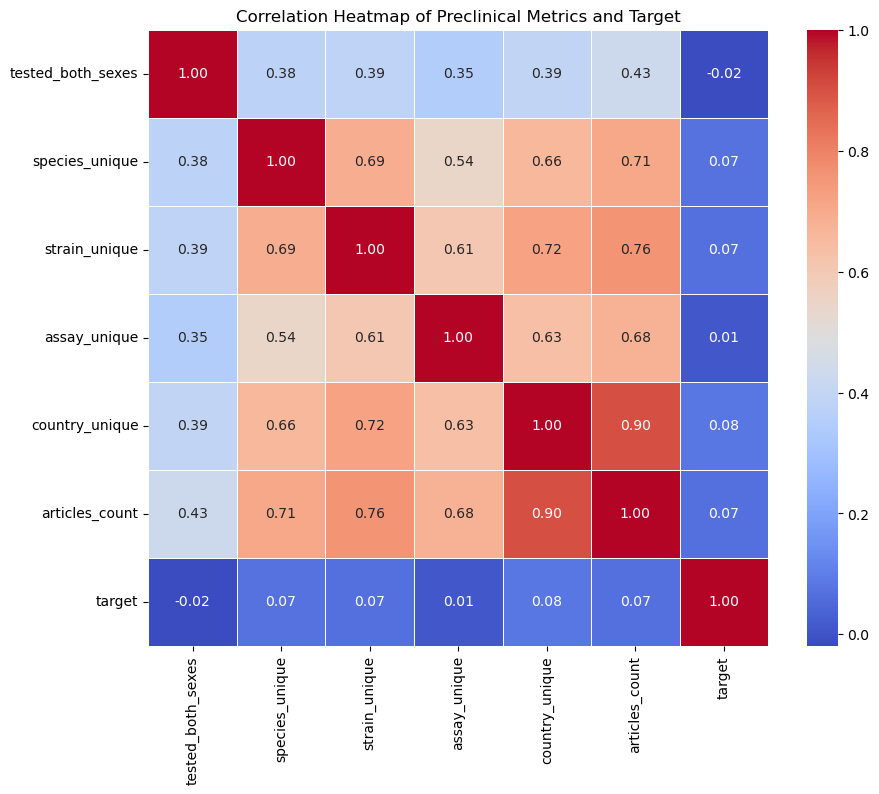

In [321]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Preclinical Metrics and Target')
plt.show()

In [322]:
from sklearn.linear_model import LogisticRegression # does it use regularization/ penalty by default? -> should be without penalization
from sklearn.preprocessing import StandardScaler # better without this -> bad for the binary variable, std dev of binary variable does not make sense
df = all_entities.copy()
# Prepare data
X = df[['species_unique', 'strain_unique', 'assay_unique', 'tested_both_sexes']]
y = df['target']

# Standardize (important for comparing coefficients)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit model
model = LogisticRegression()
model.fit(X_scaled, y)

# View importance
importance = pd.Series(model.coef_[0], index=X.columns)
print("Feature Importance (Log-Odds):")
print(importance.sort_values(ascending=False))

Feature Importance (Log-Odds):
species_unique       0.182121
strain_unique        0.040040
tested_both_sexes   -0.027380
assay_unique        -0.067121
dtype: float64


In [323]:
from sklearn.linear_model import LogisticRegression # does it use regularization/ penalty by default? -> should be without penalization
from sklearn.preprocessing import StandardScaler # better without this -> bad for the binary variable, std dev of binary variable does not make sense
# exp = odds ratio when i increase species by one
# idea: table with p-values and confidence intervals -> summary of the GLM fit -> 
# model selection -> cross validation
# missing data -> is it systematic? if it is related to a variable that has been collected it could be imputed -> try to omit missing ones
# forest plot for the coeff -> estimates + confidence interval (p-value); also case with multilpe imputations -> sensitivity analysis -> MICE package in R -> only if NOT "missing not at random"
# dorest plot at loggs ratio scale-> what increases/ decreases success -> conf interval!!
# check forest plot packages in R -> point estimate, conf interval, variable names -> give GLM object, get forest 

df = all_entities.copy()
# Prepare data
X = df[['species_unique', 'strain_unique', 'assay_unique', 'tested_both_sexes']]
y = df['target']

# Standardize (important for comparing coefficients)
scaler = StandardScaler()
X_scaled = X.copy()

# Fit model
model = LogisticRegression()
model.fit(X_scaled, y)

# View importance
importance = pd.Series(model.coef_[0], index=X.columns)
print("Feature Importance (Log-Odds):")
print(importance.sort_values(ascending=False))

Feature Importance (Log-Odds):
species_unique       0.179474
strain_unique        0.010181
assay_unique        -0.048800
tested_both_sexes   -0.055044
dtype: float64


In [324]:
from sklearn.linear_model import LogisticRegression # does it use regularization/ penalty by default? -> should be without penalization

df = all_entities.copy()
# Prepare data
X = df[['species_unique', 'strain_unique', 'assay_unique', 'tested_both_sexes']]
y = df['target']

X_scaled = X.copy()

# Fit model
model = LogisticRegression(
    penalty="none",
    solver="lbfgs",
    max_iter=1000
)
model.fit(X_scaled, y)

# View importance
importance = pd.Series(model.coef_[0], index=X.columns)
print("Feature Importance (Log-Odds):")
print(importance.sort_values(ascending=False))

Feature Importance (Log-Odds):
species_unique       0.179739
strain_unique        0.010171
assay_unique        -0.048843
tested_both_sexes   -0.055230
dtype: float64


/home/sdonev/data/conda/envs/torch-huggingface/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1182: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(


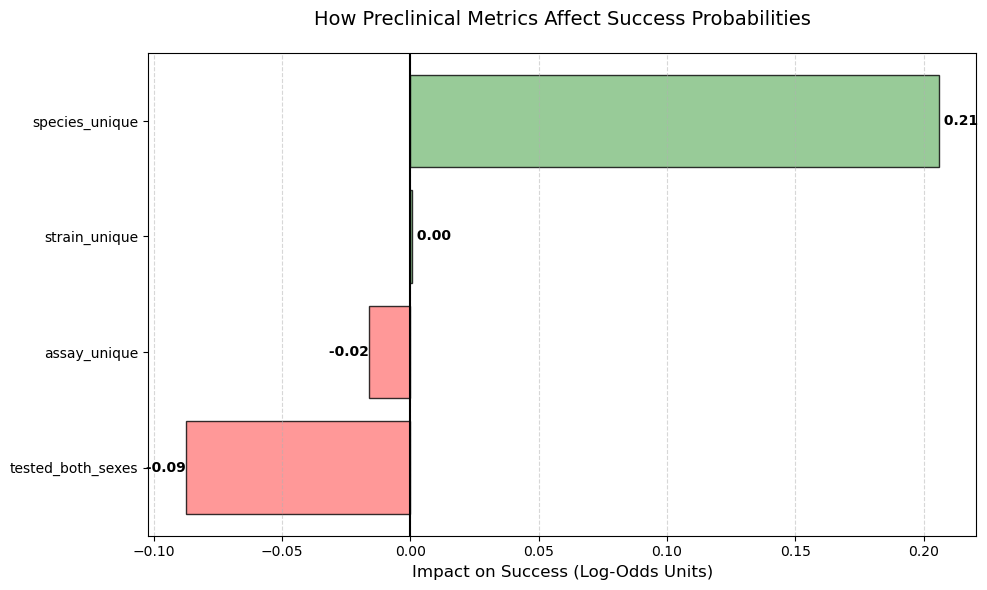

In [325]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare the data
data = {
    'Feature': ['species_unique', 'strain_unique', 'assay_unique', 'tested_both_sexes'],
    'Log-Odds': [0.205871, 0.000613, -0.016262, -0.087504]
}

df_importance = pd.DataFrame(data).sort_values(by='Log-Odds', ascending=True)

# 2. Create the plot
plt.figure(figsize=(10, 6))
# Use green for positive impact and red for negative
colors = ['#ff7f7f' if x < 0 else '#7fbf7f' for x in df_importance['Log-Odds']]
bars = plt.barh(df_importance['Feature'], df_importance['Log-Odds'], color=colors, edgecolor='black', alpha=0.8)

# 3. Add styling
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5) # Reference line at 0
plt.xlabel('Impact on Success (Log-Odds Units)', fontsize=12)
plt.title('How Preclinical Metrics Affect Success Probabilities', fontsize=14, pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 4. Label the bars with the actual values
for bar in bars:
    width = bar.get_width()
    label_x_pos = width if width > 0 else width
    plt.text(label_x_pos, bar.get_y() + bar.get_height()/2, f' {width:.2f}', 
             va='center', ha='left' if width > 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance_plot.png')

## Sample data for validation

In [326]:
sampled_df = pd.concat([
    all_entities[all_entities["target"] == 1].sample(n=5, random_state=42),
    all_entities[all_entities["target"] == 0].sample(n=5, random_state=42)
])
sampled_df

,drug_name,tested_both_sexes,species_unique,strain_unique,assay_unique,country_unique,articles_count,target
3807,major depressive disorder <> benzodiazepine,0,1,1,1,1,1,1
5108,toxic labyrinthitis <> thiosulfates,1,2,1,3,3,4,1
4241,obsolete disorder involving pain <> ibuprofen ...,0,1,1,3,1,1,1
2324,amyotrophic lateral sclerosis <> granulocyte c...,1,2,2,4,3,6,1
5058,substance-induced psychosis <> aripiprazole,0,1,1,1,1,1,1
544,cognitive disorder <> epigallocatechin gallate,0,2,1,4,2,2,0
1986,substance dependence <> propranolol,0,1,1,1,1,1,0
420,carpal tunnel syndrome <> triamcinolone,0,1,1,3,1,1,0
527,cocaine dependence <> cocaethylene,0,1,0,1,1,1,0
196,arteriosclerosis disorder <> 1-(5-isoquinoline...,0,1,1,2,1,1,0


In [327]:
numeric_cols = [
    "tested_both_sexes",
    "species_unique",
    "strain_unique",
    "assay_unique",
    "country_unique",
]

# compute z-scores
z_scores = (
    all_entities[numeric_cols]
    .apply(lambda x: (x - x.mean()) / x.std())
    .abs()
)

# mark outliers (any column with z > 2.5)
outliers = all_entities[z_scores.max(axis=1) > 2.5]

outlier_sample = outliers.sample(n=5, random_state=42)
outlier_sample

,drug_name,tested_both_sexes,species_unique,strain_unique,assay_unique,country_unique,articles_count,target
3347,epilepsy with generalized tonic-clonic seizure...,1,5,10,4,7,18,1
127,alzheimer disease <> ubidecarenone,1,2,13,5,11,21,0
3529,hiv infectious disease <> tenofovir,1,6,11,5,10,29,1
1766,schizophrenia <> amphetamine,1,5,30,5,16,70,0
2988,depressive disorder <> buspirone,1,2,11,4,14,33,1


In [328]:
combined_preclin_df.head()

,normalized_key,merged_mondo_label,merged_umls_label,PMID,title,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_strain,animal_number,assay_type,first_author_country,study_classification,rigor_blinding_binary,rigor_randomization_binary,rigor_welfare_binary,sample_size_binary
0,drug dependence <> cocaine,drug dependence,cocaine,21790900,Addictive potential of modafinil and cross-sen...,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,male,Swiss,"[22.0, 27.0, 50.0, 52.0, 24.0]","Behavioral, Molecular & Cellular",Brazil,failed,0,1,1,0
1,cocaine dependence <> cocaine,cocaine dependence,cocaine,21790900,Addictive potential of modafinil and cross-sen...,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,male,Swiss,"[22.0, 27.0, 50.0, 52.0, 24.0]","Behavioral, Molecular & Cellular",Brazil,failed,0,1,1,0
2,drug dependence <> cocaine,drug dependence,cocaine,29227643,Structure-Activity Relationship Studies on a S...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"mouse, rat",male,"Sprague-Dawley,SwissWebster",not reported,Molecular & Cellular,USA,failed,0,0,0,0
3,cocaine dependence <> cocaine,cocaine dependence,cocaine,29227643,Structure-Activity Relationship Studies on a S...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"mouse, rat",male,"Sprague-Dawley,SwissWebster",not reported,Molecular & Cellular,USA,failed,0,0,0,0
4,drug dependence <> cocaine,drug dependence,cocaine,10485969,Rapid induction of behavioral and neurochemica...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,not-reported,not reported,not reported,Molecular & Cellular,USA,failed,0,0,0,0


In [329]:
sampled_and_outliers_df = pd.concat([
    sampled_df,
    outlier_sample
])
sampled_and_outliers_df

,drug_name,tested_both_sexes,species_unique,strain_unique,assay_unique,country_unique,articles_count,target
3807,major depressive disorder <> benzodiazepine,0,1,1,1,1,1,1
5108,toxic labyrinthitis <> thiosulfates,1,2,1,3,3,4,1
4241,obsolete disorder involving pain <> ibuprofen ...,0,1,1,3,1,1,1
2324,amyotrophic lateral sclerosis <> granulocyte c...,1,2,2,4,3,6,1
5058,substance-induced psychosis <> aripiprazole,0,1,1,1,1,1,1
544,cognitive disorder <> epigallocatechin gallate,0,2,1,4,2,2,0
1986,substance dependence <> propranolol,0,1,1,1,1,1,0
420,carpal tunnel syndrome <> triamcinolone,0,1,1,3,1,1,0
527,cocaine dependence <> cocaethylene,0,1,0,1,1,1,0
196,arteriosclerosis disorder <> 1-(5-isoquinoline...,0,1,1,2,1,1,0


In [330]:
out_dir="./data/translation_validation"
def safe_filename(s: str) -> str:
    s = s.strip()
    s = re.sub(r"[^\w\-<> ]+", "", s)
    s = s.replace(" <> ", "_")
    s = re.sub(r"\s+", "_", s)
    return s[:200]

# df_drugs must contain: drug_name, target
for _, row in (
    sampled_and_outliers_df[["drug_name", "target"]]
    .dropna()
    .drop_duplicates()
    .iterrows()
):
    key = row["drug_name"]
    target = int(row["target"])

    prefix = "positive_" if target == 1 else "negative_"

    sub = combined_preclin_df[
        combined_preclin_df["normalized_key"] == key
    ].copy()

    if sub.empty:
        continue
        

    if len(sub) > 5:
        sub = sub.sample(n=5, random_state=42)
        
    fname = prefix + safe_filename(key) + ".csv"
    path = os.path.join(out_dir, fname)

    sub.to_csv(path, index=False)

print(f"Saved per-drug CSVs with target prefix to: {out_dir}")

Saved per-drug CSVs with target prefix to: ./data/translation_validation


In [331]:
sampled_and_outliers_df.to_csv(out_dir+"/sampled_and_outliers_df.csv",index=False)

In [332]:
 combined_preclin_df[
        combined_preclin_df["normalized_key"] == "epilepsy <> phenytoin"
    ].to_csv(out_dir +"/epilepsy_phenytoin_all.csv",index=False)

In [333]:
combined_preclin_df[
    (combined_preclin_df["normalized_key"] == "focal epilepsy <> carbamazepine") &
    (combined_preclin_df["animal_species"].str.contains("dog"))
]


,normalized_key,merged_mondo_label,merged_umls_label,PMID,title,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_strain,animal_number,assay_type,first_author_country,study_classification,rigor_blinding_binary,rigor_randomization_binary,rigor_welfare_binary,sample_size_binary


In [72]:
combined_preclin_df[
    (combined_preclin_df["normalized_key"] == "focal epilepsy <> carbamazepine")
].animal_species

19702       guinea pig
20333            mouse
20945              rat
21419              rat
21477              rat
21945              rat
22034              rat
22047       mouse, rat
22169            mouse
22177              rat
24222              rat
24225            mouse
24692           rabbit
24693              rat
24695      pig, rabbit
24696    species-other
24697              pig
Name: animal_species, dtype: object

In [39]:
combined_preclin_df[combined_preclin_df['PMID']==24878681]

,normalized_key,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_age,animal_strain,animal_number,assay_type,first_author_country,merged_mondo_label,merged_umls_label,study_classification
31101,brain ischemia <> sevoflurane,24878681,A combination of mild hypothermia and sevoflur...,brain hypoxia - ischemia|brain|perinatal asphyxia,sevoflurane,blinding-not-reported,randomization-present,welfare-not-reported,sample-size-not-reported,mouse,not-reported,not reported,not reported,"[19.0, 22.0, 29.0]","Behavioral, Histology, Molecular & Cellular, P...",USA,brain hypoxia - ischemia|brain|perinatal asphy...,sevoflurane,approved
31102,brain hypoxia - ischemia <> sevoflurane,24878681,A combination of mild hypothermia and sevoflur...,brain hypoxia - ischemia|brain|perinatal asphyxia,sevoflurane,blinding-not-reported,randomization-present,welfare-not-reported,sample-size-not-reported,mouse,not-reported,not reported,not reported,"[19.0, 22.0, 29.0]","Behavioral, Histology, Molecular & Cellular, P...",USA,brain hypoxia - ischemia|brain|perinatal asphy...,sevoflurane,approved


# Viz Drug-Disease Clinical x Preclinical

In [558]:
import os
import numpy as np
import matplotlib.pyplot as plt

def viz_joined_preclin_clinical(
    filtered_df,
    normalized_key="normalized_condition",
    additional_sort_by="both",
    translation_column=None,
    top_n=25,
    fig_name_suffix="",
    save_to="png",
    save_path="06_preclin_clinic_join/viz",
):
    """
    Visualizes the top N normalized conditions with:
      - Preclinical Count
      - Preclinical Count Before Clinical
      - Clinical Count
    as grouped horizontal bars.

    Adds ♦ and min_relevant_clinical_year next to clinical count if translation_column is True.
    """

    # --- select top N ---
    if additional_sort_by == "both":
        top_n_df = filtered_df.head(top_n)
        title_str = "Clinical + Preclinical Count"
    elif additional_sort_by == "clinical_count":
        top_n_df = filtered_df.sort_values(by="clinical_count", ascending=False).head(top_n)
        title_str = "Clinical Count"
    elif additional_sort_by == "tail":
        top_n_df = filtered_df.tail(top_n)
        title_str = "Clinical + Preclinical Count Tail"
    else:
        top_n_df = filtered_df.sort_values(by="preclinical_count", ascending=False).head(top_n)
        title_str = "Preclinical Count"

    conditions = top_n_df[normalized_key].astype(str)
    clinical_counts = top_n_df["clinical_count"].fillna(0)
    preclinical_counts = top_n_df["preclinical_count"].fillna(0)
    preclinical_before_clinical_counts = top_n_df["preclinical_count_before_clinical"].fillna(0)
    min_years = top_n_df.get("min_relevant_clinical_year")

    y_positions = np.arange(len(conditions))
    bar_width = 0.24

    os.makedirs(save_path, exist_ok=True)

    plt.figure(figsize=(14, 10))

    # Bars
    plt.barh(y_positions - bar_width, preclinical_counts, height=bar_width,
             label="Preclinical Count", color="#56B4E9", zorder=2)

    plt.barh(y_positions, preclinical_before_clinical_counts, height=bar_width,
             label="Preclinical Before Clinical", color="#009E73", zorder=2)

    plt.barh(y_positions + bar_width, clinical_counts, height=bar_width,
             label="Clinical Count", color="#E69F00", zorder=2)

    # Labels
    for i in range(len(conditions)):

        # Preclinical total
        plt.text(preclinical_counts.iloc[i],
                 y_positions[i] - bar_width,
                 f"{preclinical_counts.iloc[i]:.0f}",
                 va="center", fontsize=13)

        # Preclinical before clinical
        plt.text(preclinical_before_clinical_counts.iloc[i],
                 y_positions[i],
                 f"{preclinical_before_clinical_counts.iloc[i]:.0f}",
                 va="center", fontsize=13)

        # Clinical + optional diamond + year
        clinical_text = f"{clinical_counts.iloc[i]:.0f}"

        if translation_column and bool(top_n_df[translation_column].iloc[i]):
            year_str = ""
            if min_years is not None and not pd.isna(min_years.iloc[i]):
                year_str = f" {int(min_years.iloc[i])}"
            clinical_text += f" ♦{year_str}"

        plt.text(clinical_counts.iloc[i],
                 y_positions[i] + bar_width,
                 clinical_text,
                 va="center", fontsize=13)

    # Axis formatting
    plt.yticks(y_positions, conditions)
    plt.xlabel("Study Count", fontsize=15)
    plt.title(f"Top {top_n} Disease-Drug Pairs by {title_str}", fontsize=18)

    if translation_column:
        plt.legend(
            handles=[
                plt.Line2D([0], [0], color="#56B4E9", lw=6, label="Preclinical Count"),
                plt.Line2D([0], [0], color="#009E73", lw=6, label="Preclinical Before Clinical"),
                plt.Line2D([0], [0], color="#E69F00", lw=6, label="Clinical Count"),
                plt.Line2D([0], [0], color="black", marker="D", linestyle="",
                           label="At least one Phase 4 trial (♦ year shown)"),
            ],
            loc="lower right",
            fontsize=12,
        )
    else:
        plt.legend(loc="lower right", fontsize=12)

    plt.tick_params(axis="both", labelsize=12)
    plt.gca().invert_yaxis()
    plt.grid(axis="x", linestyle="--", alpha=0.4, color="gray", zorder=0)

    plt.tight_layout()

    out_file = f"{save_path}/top{top_n}_preclin_clin{fig_name_suffix}.{save_to}"
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()


In [559]:
df_translated['translated']=True
df_failed['translated']=False

/tmp/ipykernel_2139895/1226866206.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_translated['translated']=True


In [560]:
df_combined_with_articles = pd.concat([df_failed, df_translated], axis=0, ignore_index=True)
df_combined_with_articles.shape

(12294, 38)

In [561]:
df_combined_with_articles["preclinical_count_before_clinical"] = (
    df_combined_with_articles["preclinical_count_before_clinical"]
    .fillna(df_combined_with_articles["preclinical_count_before_latest_trial"])
)


In [562]:
df_combined_with_articles_to_merge = df_combined_with_articles[['normalized_key','preclinical_count_before_clinical','translated','min_relevant_clinical_year']]
translation_table_for_viz = translation_table.merge(df_combined_with_articles_to_merge, left_on="normalized_key", right_on="normalized_key",how="left")

In [563]:
translation_table_for_viz.shape

(17158, 36)

In [564]:
translation_table_for_viz[translation_table_for_viz.normalized_key.str.contains("parkinson disease <> levodopa")]

,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,trial_completion_year,phase,overall_status,...,fda_documents,fda_disease<>drug,fda_AP,fda_only,matched_term,translation_status,min_relevant_clinical_year_x,preclinical_count_before_clinical,translated,min_relevant_clinical_year_y
12,parkinson disease <> levodopa,"['NCT00004576', 'NCT00004733', 'NCT00006077', ...",MONDO:0005180,C0023570,parkinson disease,levodopa,"[2000.0, 1998.0, 2000.0, 2000.0, 2001.0, 2001....","[2000.0, 2004.0, 2003.0, 2002.0, 2003.0, 2005....","['PHASE2', 'PHASE3', 'PHASE2', 'PHASE2', 'PHAS...","['COMPLETED', 'COMPLETED', 'COMPLETED', 'COMPL...",...,"['ANDA073589', 'ANDA073607', 'ANDA073618', 'AN...",parkinson disease <> levodopa,True,NaN,parkinson disease,approved,1975,4.0,True,1975
138,late-onset parkinson disease <> levodopa,"['NCT00009048', 'NCT00013624', 'NCT00040209', ...",MONDO:0008199,C0023570,late-onset parkinson disease,levodopa,"[2001.0, 2001.0, 2002.0, 2004.0, 2004.0, 2005....","[2003.0, 2005.0, 2005.0, 2005.0, 2007.0, nan, ...","['PHASE2', 'PHASE2', 'PHASE2', 'PHASE2', 'PHAS...","['COMPLETED', 'COMPLETED', 'COMPLETED', 'COMPL...",...,NaN,NaN,False,NaN,parkinson disease,approved,2006,0.0,True,2006
495,young-onset parkinson disease <> levodopa,"['NCT00096720', 'NCT00134784', 'NCT00134966', ...",MONDO:0017279,C0023570,young-onset parkinson disease,levodopa,"[2004.0, 2000.0, 2005.0, 2005.0, 1997.0, 2005....","[2007.0, 2007.0, 2007.0, 2009.0, 2000.0, 2008....","['PHASE2', 'PHASE2', 'PHASE3', 'PHASE4', 'PHAS...","['COMPLETED', 'COMPLETED', 'COMPLETED', 'COMPL...",...,NaN,NaN,False,NaN,young-onset parkinson disease,approved,2005,2.0,True,2005
9559,parkinson disease <> levodopa benserazide,['NCT02741947'],MONDO:0005180,-1,parkinson disease,levodopa benserazide,[2014.0],[2015.0],['PHASE4'],['COMPLETED'],...,NaN,NaN,False,NaN,parkinson disease,approved,2014,6.0,True,2014
12643,parkinson disease <> levodopa/benserazide,['NCT02741947'],MONDO:0005180,-1,parkinson disease,levodopa/benserazide,[2014.0],[2015.0],['PHASE4'],['COMPLETED'],...,NaN,NaN,False,NaN,parkinson disease,approved,2014,1.0,True,2014
15851,obsolete early-onset parkinson disease <> levo...,['NCT04978597'],MONDO:0000829,C0023570,obsolete early-onset parkinson disease,levodopa,[2021.0],[2024.0],['PHASE3'],['COMPLETED'],...,NaN,NaN,False,NaN,obsolete early-onset parkinson disease,approved,<NA>,0.0,True,<NA>


In [568]:
translation_table_for_viz[translation_table_for_viz['translated']==False].head()

,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,trial_completion_year,phase,overall_status,...,fda_disease<>drug,fda_AP,fda_only,matched_term,translation_status,min_relevant_clinical_year_x,preclinical_count_before_clinical,translated,min_relevant_clinical_year_y,key_for_viz
230,metastatic malignant neoplasm in the brain <> ...,"['NCT00003062', 'NCT00005954', 'NCT00012116', ...",MONDO:1040026,C0076080,metastatic malignant neoplasm in the brain,temozolomide,"[1997.0, 2000.0, 2000.0, 2001.0, 2001.0, 2003....","[nan, 2003.0, 2002.0, nan, 2003.0, nan, 2006.0...","['PHASE2', 'PHASE2', 'PHASE2', 'PHASE3', 'PHAS...","['COMPLETED', 'COMPLETED', 'COMPLETED', 'TERMI...",...,NaN,False,NaN,metastatic malignant neoplasm in the brain,failed,<NA>,9.0,False,2025,temozolomide\nmetastatic malignant neoplasm in...
268,brain neoplasm <> bevacizumab,"['NCT00271609', 'NCT00312728', 'NCT00393094', ...",MONDO:0021211,C0796392,brain neoplasm,bevacizumab,"[2005.0, 2006.0, 2006.0, 2007.0, 2005.0, 2007....","[2014.0, 2009.0, 2010.0, 2011.0, 2017.0, 2013....","['PHASE2', 'PHASE2', 'PHASE2', 'PHASE2', nan, ...","['COMPLETED', 'COMPLETED', 'TERMINATED', 'COMP...",...,NaN,False,NaN,brain neoplasm,failed,<NA>,12.0,False,2024,bevacizumab\nbrain neoplasm
291,glioblastoma <> irinotecan,"['NCT00010036', 'NCT00027612', 'NCT00039468', ...",MONDO:0018177,C0123931,glioblastoma,irinotecan,"[1999.0, 2002.0, 2002.0, 2004.0, 2005.0, 2006....","[nan, 2009.0, 2008.0, 2013.0, 2011.0, 2007.0, ...","['PHASE2', 'PHASE1/PHASE2', 'PHASE2', 'PHASE2'...","['COMPLETED', 'COMPLETED', 'COMPLETED', 'COMPL...",...,NaN,False,NaN,glioblastoma,failed,<NA>,23.0,False,2017,irinotecan\nglioblastoma
292,high grade astrocytic tumor <> irinotecan,"['NCT00010036', 'NCT00027612', 'NCT00039468', ...",MONDO:0016680,C0123931,high grade astrocytic tumor,irinotecan,"[1999.0, 2002.0, 2002.0, 2004.0, 2005.0, 2006....","[nan, 2009.0, 2008.0, 2013.0, 2011.0, 2007.0, ...","['PHASE2', 'PHASE1/PHASE2', 'PHASE2', 'PHASE2'...","['COMPLETED', 'COMPLETED', 'COMPLETED', 'COMPL...",...,NaN,False,NaN,astrocytic tumor,failed,<NA>,22.0,False,2017,irinotecan\nhigh grade astrocytic tumor
296,anxiety disorder <> psilocybin,"['NCT00302744', 'NCT00465595', 'NCT00957359', ...",MONDO:0005618,C0033850,anxiety disorder,psilocybin,"[2004.0, 2007.0, 2009.0, 2012.0, 2012.0, 2017....","[2008.0, 2016.0, 2018.0, 2013.0, 2014.0, 2021....","['PHASE1/PHASE2', 'PHASE2', 'EARLY_PHASE1', 'P...","['COMPLETED', 'COMPLETED', 'COMPLETED', 'WITHD...",...,NaN,False,NaN,anxiety disorder,failed,<NA>,10.0,False,2025,psilocybin\nanxiety disorder


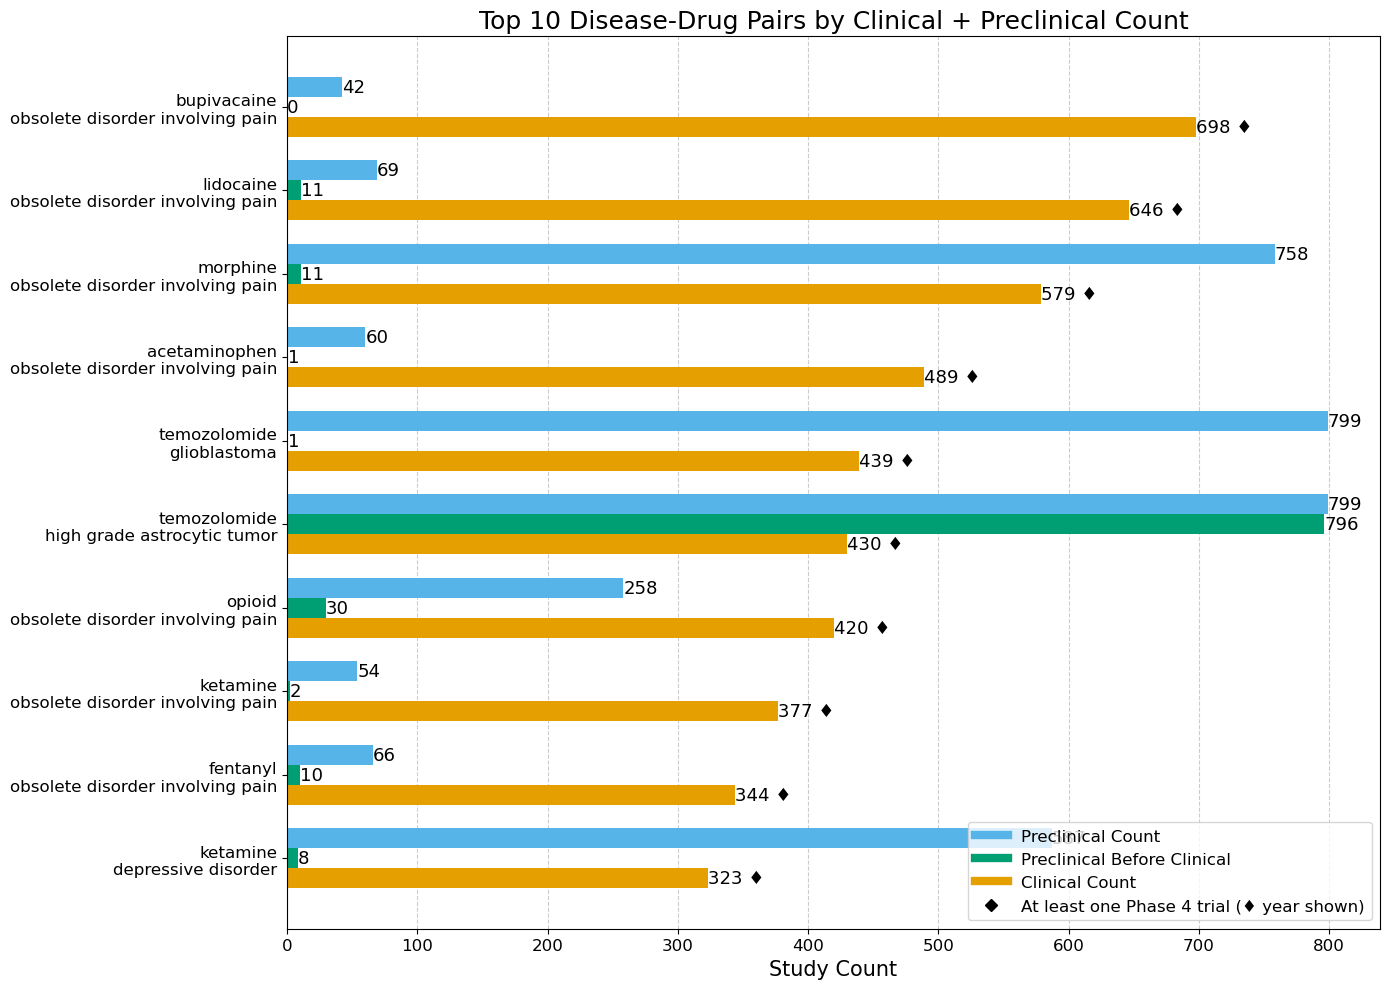

In [567]:
# ------------------------- #
#         VISUALIZE         #
# ------------------------- #
translation_table_for_viz['key_for_viz'] = (
    translation_table_for_viz['merged_umls_label'] + "\n" + translation_table_for_viz['merged_mondo_label']
)

viz_joined_preclin_clinical(
    translation_table_for_viz,
    "key_for_viz",
    translation_column='translated',
    top_n=10,
    fig_name_suffix='',
    save_path="viz/"
)


In [344]:
translation_table_for_viz.translated.value_counts()

translated
True     5899
False    4252
Name: count, dtype: int64

In [346]:
translation_table_for_viz["translated"] = (
    translation_table_for_viz["translated"]
        .replace({True: "translated", False: "not translated",
                  "True": "translated", "False": "not translated"})
        .fillna("unknown")
)
plot_df = translation_table_for_viz.dropna(
    subset=["min_relevant_clinical_year_y", "preclinical_count_before_clinical"]
).copy()
plot_df.translated.value_counts()

translated
translated        5874
not translated    4252
Name: count, dtype: int64

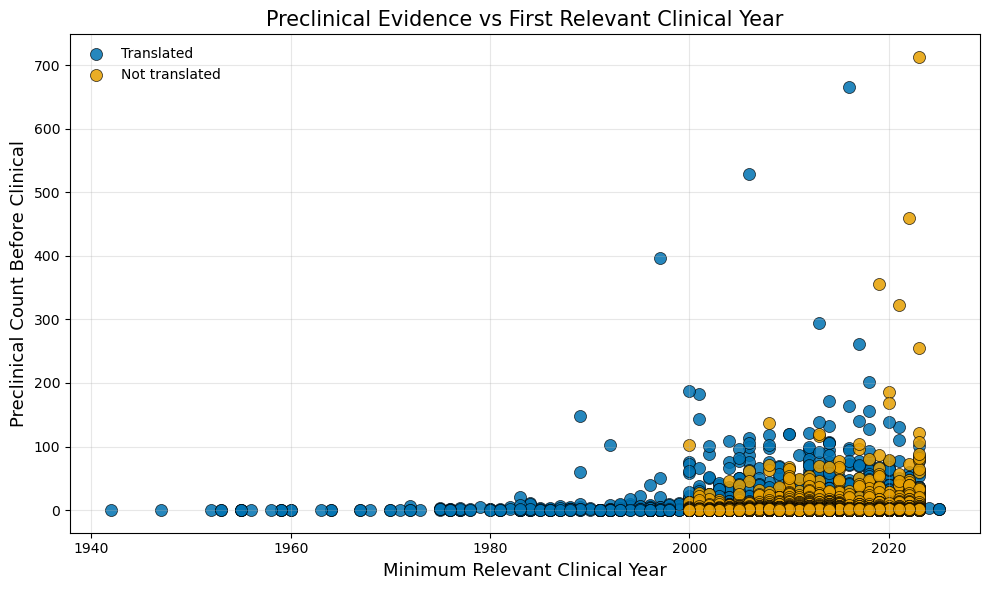

In [348]:
plt.figure(figsize=(10, 6))

# Okabe–Ito colorblind-safe palette
color_map = {
    "translated": "#0072B2",      # blue
    "not translated": "#E69F00",  # orange
    "unknown": "#999999"          # neutral grey
}

# Fixed legend order
for status in ["translated", "not translated", "unknown"]:
    subset = plot_df[plot_df["translated"] == status]

    if len(subset) == 0:
        continue

    plt.scatter(
        subset["min_relevant_clinical_year_y"],
        subset["preclinical_count_before_clinical"],
        color=color_map[status],
        edgecolor="black",
        linewidth=0.5,
        alpha=0.85,
        s=75,
        label=status.capitalize()
    )

plt.xlabel("Minimum Relevant Clinical Year", fontsize=13)
plt.ylabel("Preclinical Count Before Clinical", fontsize=13)
plt.title("Preclinical Evidence vs First Relevant Clinical Year", fontsize=15)

plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [406]:
len(failed_pmids)

11692

In [407]:
len(translated_pmids)

16997

In [422]:
preclin_dataset_year = pd.read_csv(df_path_current_dataset)[['PMID', 'year']]#, 'rigor_randomization', 'rigor_welfare', 'sample_size', 'animal_species','animal_sex','animal_strain','animal_number', 'assay_type', 'first_author_country']]

/tmp/ipykernel_2139895/708847759.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  preclin_dataset_year = pd.read_csv(df_path_current_dataset)[['PMID', 'year']]#, 'rigor_randomization', 'rigor_welfare', 'sample_size', 'animal_species','animal_sex','animal_strain','animal_number', 'assay_type', 'first_author_country']]


In [425]:
translated_df_years = preclin_dataset_year[preclin_dataset_year["PMID"].isin(translated_pmids)][["PMID", "year"]]

failed_df_years = preclin_dataset_year[preclin_dataset_year["PMID"].isin(failed_pmids)][["PMID", "year"]]

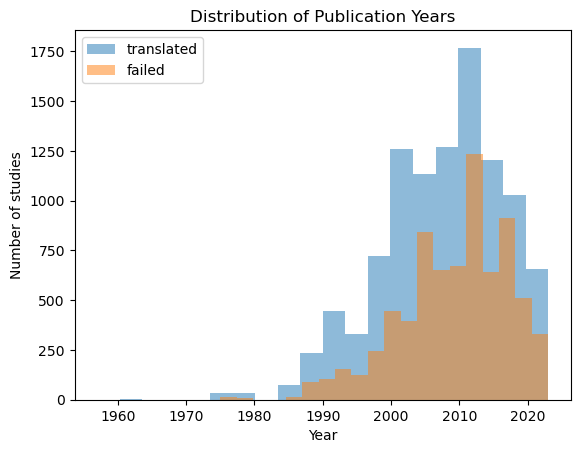

In [431]:
import pandas as pd
import matplotlib.pyplot as plt

# Build combined dataframe
translated_df_years = preclin_dataset_year[
    preclin_dataset_year["PMID"].isin(translated_pmids)
][["PMID", "year"]].copy()
translated_df_years["status"] = "translated"

failed_df_years = preclin_dataset_year[
    preclin_dataset_year["PMID"].isin(failed_pmids)
][["PMID", "year"]].copy()
failed_df_years["status"] = "failed"

plot_df = pd.concat([translated_df_years, failed_df_years], ignore_index=True)

plt.figure()

plt.hist(
    plot_df.loc[plot_df["status"] == "translated", "year"],
    bins=20,
    alpha=0.5,
    label="translated"
)

plt.hist(
    plot_df.loc[plot_df["status"] == "failed", "year"],
    bins=20,
    alpha=0.5,
    label="failed"
)

plt.xlabel("Year")
plt.ylabel("Number of studies")
plt.title("Distribution of Publication Years")
plt.legend()
plt.show()

/tmp/ipykernel_2139895/89306249.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


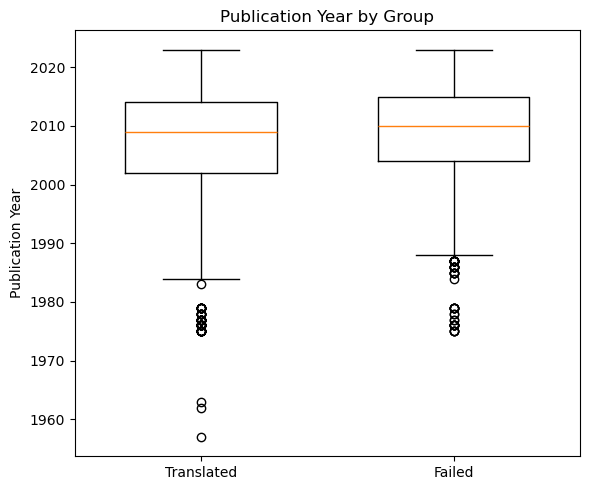

In [433]:
import pandas as pd
import matplotlib.pyplot as plt

# Build combined dataframe
translated_df_years = preclin_dataset_year[
    preclin_dataset_year["PMID"].isin(translated_pmids)
][["PMID", "year"]].copy()
translated_df_years["status"] = "Translated"

failed_df_years = preclin_dataset_year[
    preclin_dataset_year["PMID"].isin(failed_pmids)
][["PMID", "year"]].copy()
failed_df_years["status"] = "Failed"

plot_df = pd.concat([translated_df_years, failed_df_years], ignore_index=True)

# Extract year values
translated_years = plot_df.loc[plot_df["status"] == "Translated", "year"].dropna()
failed_years = plot_df.loc[plot_df["status"] == "Failed", "year"].dropna()

plt.figure(figsize=(6, 5))

plt.boxplot(
    [translated_years, failed_years],
    labels=["Translated", "Failed"],
    widths=0.6
)

plt.ylabel("Publication Year")
plt.title("Publication Year by Group")

plt.tight_layout()
plt.show()